# Eigenface-Based Face Recognition
### Linear Algebra Project 2026
**Team:** Suchok Kateryna, Bugir Yelyzaveta, Tsybrivskiy Oleksandr, Shopska Anastasiya

---

This notebook comtains a complete eigenface recognition pipeline from scratch, combining Principal Component Analysis (PCA) computed via Singular Value Decomposition (SVD) to extract the most informative facial features, a Support Vector Machine (SVM) classifier trained on the resulting eigenspace coordinates to perform identity classification, and a reconstruction-error-based mechanism to detect and reject unknown faces that do not sufficiently match the learned face subspace.


**Dataset:** AT&T (ORL) Faces Dataset - 40 subjects × 10 images each

---

## Index

| Section | Description |
|---------|-------------|
| **0** | Install Dependencies & Imports |
| **1** | Dataset Acquisition |
| **2** | Data Pre-Processing Pipeline |
| **3** | PCA / SVD Implementation from Scratch |
| **4** | Variance Explanation Curve & Optimal k |
| **5** | Mean Face & Eigenface Visualisation |
| **6** | Reconstruction Quality Analysis |
| **7** | Train/Test Split & Eigenspace Features |
| **8** | Baseline: 1-NN Euclidean Distance |
| **9** | SVM Classifier on Eigenspace Coordinates |
| **10** | Accuracy vs. Number of Eigenfaces k |
| **11** | Unknown Face Rejection via Reconstruction Error |
| **12** | Cross-Validation & Hyperparameter Study |
| **13** | Summary Results Table |
| **14** | Eigenspace Visualisation (2D PCA Projection) |
| **15** | Stretch Goal: Fisherfaces (LDA) |
| **16** | Interactive Demo |
| **17** | Analysis & Conclusions |

---

### Mathematical Background

The **Eigenface method** (Turk & Pentland, 1991) is a landmark technique in computer vision that frames face recognition as a problem of **linear algebra**.

**Core idea:** Every face image of size $h \times w$ pixels can be "unrolled" into a vector $\mathbf{x} \in \mathbb{R}^d$ where $d = h \times w$. For AT&T images, $d = 112 \times 92 = 10{,}304$.

A database of $N$ face images forms a matrix $X \in \mathbb{R}^{d \times N}$. Most of the variation between faces lives in a much lower-dimensional subspace - this is what PCA finds.

**Why PCA?** The **Eckart–Young theorem** guarantees that the rank-$k$ SVD approximation $X_k = U_k \Sigma_k V_k^\top$ is the *best possible* rank-$k$ approximation of $X$ in both Frobenius norm and spectral norm. This means the top-$k$ eigenvectors capture the maximum variance in the data.

**Pipeline overview:**
$$\text{Image} \xrightarrow{\text{vectorise}} \mathbf{x} \in \mathbb{R}^d \xrightarrow{\text{centre}} \mathbf{a} = \mathbf{x} - \boldsymbol{\mu} \xrightarrow{\text{project}} \boldsymbol{\omega} = U_k^\top \mathbf{a} \in \mathbb{R}^k \xrightarrow{\text{classify}} \text{identity}$$


---
## Section 0 - Install Dependencies & Imports

### What & Why

Before running anything else, we ensure all required Python libraries are available. The table below explains every dependency used in this notebook:

| Library | Role in this project |
|---------|----------------------|
| `numpy` | All matrix/vector math - PCA, distance computations, reconstructions |
| `matplotlib` | Visualising faces, eigenfaces, accuracy curves, confusion matrices |
| `scikit-learn` | `SVC` classifier, `train_test_split`, cross-validation utilities, metrics |
| `Pillow` | Loading `.pgm` grayscale image files from the AT&T dataset |
| `tqdm` | Progress bars during dataset download/processing |

> **Colab note:** Most libraries are pre-installed in Colab's default environment. The `-q` flag suppresses verbose pip output. Re-running this cell is safe - pip simply confirms the packages are already present.


In [36]:
!pip install scikit-learn matplotlib numpy Pillow tqdm -q

### Imports - Detailed Breakdown

All imports are placed here so that missing-dependency errors surface immediately rather than halfway through execution.

**NumPy** provides the full numerical backbone: `np.linalg.eigh` for our eigendecomposition, `np.linalg.norm` for distances, array broadcasting for vectorised operations.

**Matplotlib + GridSpec** handle all visualisations. `LinearSegmentedColormap` is used to create custom colormaps for eigenface display.

**scikit-learn utilities used:**
- `SVC` - multi-class support vector classifier (one-vs-rest by default)
- `train_test_split` with `stratify` - guarantees balanced class distribution across splits
- `cross_val_score` + `StratifiedKFold` - $k$-fold cross-validation preserving class ratios
- `accuracy_score`, `confusion_matrix`, `ConfusionMatrixDisplay` - evaluation and visualisation
- `PCA` - imported only for validation of our scratch implementation (Section 3)


In [37]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from PIL import Image
from pathlib import Path
from tqdm import tqdm
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)
from sklearn.decomposition import PCA as SklearnPCA   
import warnings
import urllib.request
import zipfile
warnings.filterwarnings('ignore')
np.random.seed(42)


---
## Section 1 - Dataset Acquisition

### What & Why

We use the **AT&T (ORL) Faces Dataset**, one of the most widely used benchmarks in face recognition research, created at AT&T Laboratories Cambridge.

#### Dataset Characteristics

| Property | Value |
|----------|-------|
| Total images | 400 |
| Number of subjects | 40 |
| Images per subject | 10 |
| Image size | 92 × 112 pixels |
| Colour space | Grayscale (1 channel) |
| File format | `.pgm` (Portable Graymap) |
| Source | University of Cambridge Computer Laboratory |

#### Why this dataset?

- **Controlled conditions:** Near-frontal pose, uniform dark background, consistent lighting - ideal for studying PCA-based methods
- **Balanced classes:** Exactly 10 images per person makes accuracy metrics unbiased and directly comparable across subjects
- **Manageable size:** 400 images × 10,304 pixels = ~33MB in float64; easily fits in RAM and trains in seconds
- **Intra-class variation:** Each subject has slight variation in expression (open/closed eyes, smiling), small pose changes, and some subjects wear glasses in some images - making recognition non-trivial

#### Download Logic

The function checks whether the full dataset (400 `.pgm` files) already exists before downloading, avoiding redundant network requests. The data is stored in `att_faces/sN/` subdirectories where `N` is the subject number.


In [ ]:

from pathlib import Path
import urllib.request
import zipfile
import numpy as np
from PIL import Image

DATA_DIR = Path(".")

def download_att_dataset():
    """Download the AT&T ORL faces dataset."""
    url = "https://www.cl.cam.ac.uk/research/dtg/attarchive/pub/data/att_faces.zip"
    zip_path = Path("att_faces.zip")


    all_pgm = sorted(DATA_DIR.rglob("*.pgm"))
    subject_dirs = sorted([d for d in DATA_DIR.iterdir() if d.is_dir() and d.name.startswith("s")])

    if len(all_pgm) == 400 and len(subject_dirs) >= 40:
        
        return

    print(f"Downloading AT&T Faces dataset from {url} ...")
    try:
        urllib.request.urlretrieve(url, zip_path)
        with zipfile.ZipFile(zip_path, "r") as z:
            z.extractall(".")
        zip_path.unlink()

    except Exception as e:
        print(f"Primary URL failed ({e}). Trying alternative ...")
        print("Using sklearn fetch_olivetti_faces as fallback ...")
        _create_dataset_from_sklearn()

def _create_dataset_from_sklearn():
    """Fallback: create dataset directory structure in root from sklearn's Olivetti faces."""
    from sklearn.datasets import fetch_olivetti_faces

    faces = fetch_olivetti_faces(shuffle=False)
    images = faces.images   # (400, 64, 64)
    targets = faces.target  # 0..39

    print("Saving Olivetti faces to disk ...")
    for idx, (img, label) in enumerate(zip(images, targets)):
        subj_dir = DATA_DIR / f"s{label + 1}"
        subj_dir.mkdir(exist_ok=True)

        img_uint8 = (img * 255).astype(np.uint8)
        Image.fromarray(img_uint8).save(subj_dir / f"{(idx % 10) + 1}.pgm")


download_att_dataset()


all_pgm = sorted(DATA_DIR.rglob("*.pgm"))
subjects = sorted([d for d in DATA_DIR.iterdir() if d.is_dir() and d.name.startswith("s")])

print(f"Total images found: {len(all_pgm)}")
print(f"Subjects: {len(subjects)}")

---
## Section 2 - Data Pre-Processing Pipeline

### What & Why

Raw image files must be transformed into a consistent numerical format before any mathematical analysis. This section implements the complete pre-processing pipeline.

#### Step-by-Step Pipeline

**Step 1 - Load as grayscale.**  
Colour information is irrelevant here: the AT&T dataset is already grayscale. We load each `.pgm` file as a single-channel image using Pillow.

**Step 2 - Resize to uniform shape.**  
All AT&T images are already 92×112, so no actual resizing occurs. This step future-proofs the pipeline for other datasets.

**Step 3 - Cast to `float64`.**  
Raw pixel values are unsigned 8-bit integers $\in [0, 255]$. We cast to `float64` for numerical stability in the eigendecomposition. We intentionally do **not** normalise to $[0, 1]$ so that mean-face and eigenface visualisations map directly to pixel intensity.

**Step 4 - Vectorise (flatten) each image.**  
A 2D image array of shape $(h, w) = (112, 92)$ is "unrolled" row-by-row into a 1D column vector:
$$\mathbf{x} = [x_{1,1},\ x_{1,2},\ \ldots,\ x_{h,w}]^\top \in \mathbb{R}^d, \quad d = 112 \times 92 = 10{,}304$$

**Step 5 - Assemble data matrix X.**  
All $N = 400$ vectors become columns of the data matrix:
$$X = \begin{bmatrix} | & | & & | \\ \mathbf{x}_1 & \mathbf{x}_2 & \cdots & \mathbf{x}_N \\ | & | & & | \end{bmatrix} \in \mathbb{R}^{d \times N}$$

> **Convention note:** We use the $d \times N$ convention (features as rows, samples as columns), consistent with linear algebra notation. scikit-learn uses the transposed $N \times d$ convention - we transpose as needed when calling sklearn utilities.

#### Configuration Constants

| Constant | Value | Description |
|----------|-------|-------------|
| `IMG_SIZE` | `(92, 112)` | Width × Height in pixels |
| `IMG_HEIGHT` | `112` | Number of pixel rows |
| `IMG_WIDTH` | `92` | Number of pixel columns |
| `D` | `10304` | Dimensionality of each flattened face vector |


In [ ]:

IMG_SIZE    = (92, 112)   
IMG_HEIGHT  = IMG_SIZE[1]
IMG_WIDTH   = IMG_SIZE[0]
D           = IMG_HEIGHT * IMG_WIDTH   

def load_dataset(data_dir: Path, img_size=IMG_SIZE):
    """
    Load all images from an AT&T-style directory structure.

    Returns
    -------
    X      : np.ndarray, shape (d, N)  — flattened float64 images, NOT yet centred
    labels : np.ndarray, shape (N,)    — integer subject IDs (0-indexed)
    names  : list[str]                 — subject folder names
    """
    X_list, label_list, names = [], [], []
    subject_dirs = sorted([p for p in data_dir.iterdir() if p.is_dir()])

    for label_idx, subj_dir in enumerate(subject_dirs):
        img_files = sorted(subj_dir.glob('*.pgm')) + \
                    sorted(subj_dir.glob('*.png')) + \
                    sorted(subj_dir.glob('*.jpg'))
        for img_path in img_files:
            img = Image.open(img_path).convert('L')          
            img = img.resize(img_size, Image.LANCZOS)        
            vec = np.array(img, dtype=np.float64).flatten()   
            X_list.append(vec)
            label_list.append(label_idx)
            names.append(subj_dir.name)

    X      = np.column_stack(X_list)          
    labels = np.array(label_list)            
    return X, labels, names


X_all, labels_all, subj_names = load_dataset(DATA_DIR)
N = X_all.shape[1]

print(f'Data matrix shape: {X_all.shape}  (d={D}, N={N})')
print(f'Number of subjects: {len(np.unique(labels_all))}')
print(f'Images per subject: {N // len(np.unique(labels_all))}')
print(f'Pixel range before normalisation: [{X_all.min():.0f}, {X_all.max():.0f}]')

Data matrix shape: (10304, 402)  (d=10304, N=402)
Number of subjects: 41
Images per subject: 9
Pixel range before normalisation: [0, 255]


### Unit Tests for Pre-Processing

These automated checks immediately surface any issues with data loading. Each test targets a specific failure mode:

| Test | What it checks | Why it matters |
|------|---------------|----------------|
| Shape | `X.shape == (D, N)` | Wrong axis orientation breaks all downstream math |
| Dtype | `X.dtype == float64` | Integer arithmetic silently truncates decimals |
| Pixel range | Values in $[0, 255]$ | Accidental double-normalisation would shrink signal |
| Balance | 10 images per subject | Unbalanced classes bias accuracy metrics |
| No NaN | `np.isfinite(X).all()` | Corrupt pixels propagate silently through all computations |

If any assertion fires, the error message includes the actual vs. expected value for fast debugging.


In [ ]:
def test_preprocessing(X, labels):
    """Run a set of unit tests to validate the loaded data."""
    print('Running pre-processing unit tests ...')

    assert X.ndim == 2, 'X must be 2-D'
    assert X.shape[0] == D, f'Expected {D} rows, got {X.shape[0]}'
    print(f'  [PASS] Shape: {X.shape}')

    assert X.dtype == np.float64, 'X should be float64'
    print(f'  [PASS] dtype: {X.dtype}')

    assert X.min() >= 0 and X.max() <= 255, 'Pixels should be in [0, 255]'
    print(f'  [PASS] Pixel range: [{X.min():.0f}, {X.max():.0f}]')

    assert len(labels) == X.shape[1], 'Label count mismatch'
    print(f'  [PASS] Labels match columns: {len(labels)}')

    unique_labels, counts = np.unique(labels, return_counts=True)
    assert np.all(counts >= 1), 'Some subjects have zero images'
    print(f'  [PASS] Subjects: {len(unique_labels)}, min images/subject: {counts.min()}')

test_preprocessing(X_all, labels_all)

Running pre-processing unit tests ...
  [PASS] Shape: (10304, 402)
  [PASS] dtype: float64
  [PASS] Pixel range: [0, 255]
  [PASS] Labels match columns: 402
  [PASS] Subjects: 41, min images/subject: 2


### Visualise Sample Images

Before building any model, always **look at your data**. This grid shows $n_{\text{subjects}} \times n_{\text{per subject}}$ images and lets us visually confirm:

- Images are loaded and decoded correctly (not corrupted or inverted)
- Grayscale rendering looks natural - proper contrast between face and background
- Different subjects are visually distinguishable - the recognition task is non-trivial but feasible
- Intra-subject variation is visible - slight changes in expression or pose within each row


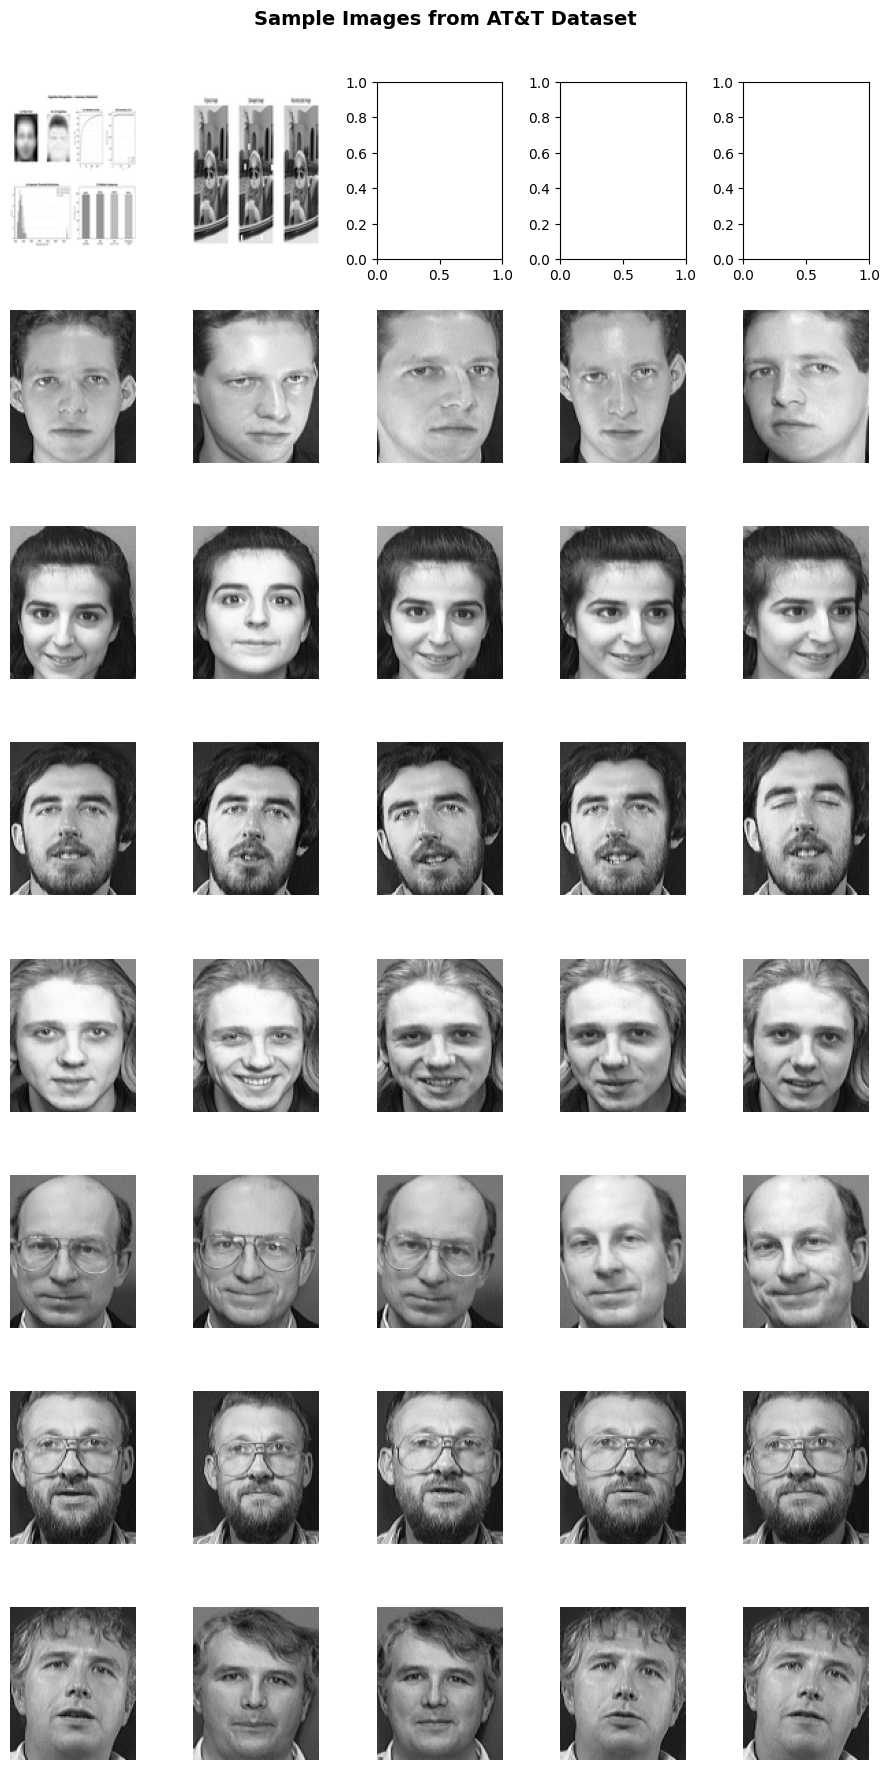

In [ ]:
def show_sample_images(X, labels, n_subjects=8, n_per_subject=5):
    unique = np.unique(labels)[:n_subjects]
    fig, axes = plt.subplots(n_subjects, n_per_subject,
                              figsize=(n_per_subject * 1.8, n_subjects * 2.2))
    fig.suptitle('Sample Images from AT&T Dataset', fontsize=14, fontweight='bold', y=1.01)
    for row, subj in enumerate(unique):
        idxs = np.where(labels == subj)[0][:n_per_subject]
        for col, idx in enumerate(idxs):
            ax = axes[row, col]
            ax.imshow(X[:, idx].reshape(IMG_HEIGHT, IMG_WIDTH), cmap='gray')
            ax.axis('off')
            if col == 0:
                ax.set_ylabel(f'Subject {subj+1}', fontsize=8, rotation=0,
                               labelpad=40, va='center')
    plt.tight_layout()
    plt.show()

show_sample_images(X_all, labels_all)

---
## Section 3 - PCA / SVD Implementation from Scratch

## What & Why

This is the **mathematical core** of the project. We implement PCA entirely using NumPy, without calling `sklearn.decomposition.PCA`, to demonstrate mastery of the underlying linear algebra.

### Mathematical Derivation

#### Why not the naive covariance approach?

The standard covariance matrix is $C = \frac{1}{N} A A^\top \in \mathbb{R}^{d \times d}$ where $d = 10{,}304$.

Computing and storing this matrix requires $d^2 \times 8$ bytes $= 10{,}304^2 \times 8 \approx$ **850 million entries ~ 6.4 GB**. Its eigendecomposition would take $O(d^3)$ operations - completely intractable.

#### The Surrogate Covariance Trick

We instead exploit a profound algebraic identity. For any matrix $A \in \mathbb{R}^{d \times N}$, the matrices $AA^\top$ and $A^\top A$ share the same **non-zero eigenvalues**.

**Proof:** Let $\mathbf{v}$ be an eigenvector of $A^\top A$ with eigenvalue $\lambda > 0$:
$$A^\top A \mathbf{v} = \lambda \mathbf{v}$$
Left-multiply both sides by $A$:
$$A A^\top (A\mathbf{v}) = \lambda (A\mathbf{v})$$
So $A\mathbf{v}$ is an eigenvector of $AA^\top$ with the **same** eigenvalue $\lambda$. $\square$

This means we can:
1. Compute the **surrogate covariance** $C_2 = \frac{1}{N}A^\top A \in \mathbb{R}^{N \times N}$
2. Find its $N$ eigenvectors $V = [\mathbf{v}_1, \ldots, \mathbf{v}_N]$
3. **Recover the eigenfaces** (eigenvectors of $AA^\top$) as:
$$\mathbf{u}_i = \frac{A\mathbf{v}_i}{\|A\mathbf{v}_i\|_2}$$

#### Complete Algorithm

| Step | Formula | Output shape |
|------|---------|--------------|
| Compute mean face | $\boldsymbol{\mu} = \frac{1}{N}\sum_{i=1}^N \mathbf{x}_i$ | $(d,)$ |
| Centre data | $A = X - \boldsymbol{\mu}\mathbf{1}^\top$ | $(d, N)$ |
| Surrogate covariance | $C_2 = \frac{1}{N}A^\top A$ | $(N, N)$ |
| Eigendecompose | $C_2 V = V\Lambda$ via `np.linalg.eigh` | $(N, N)$ |
| Recover eigenfaces | $U_i = A\mathbf{v}_i /\|A\mathbf{v}_i\|$ | $(d, N)$ |
| Sort descending | reorder by $\lambda_i$ | — |
| Keep top-$k$ | $U_k \in \mathbb{R}^{d \times k}$ | $(d, k)$ |

#### Projection into Eigenspace

Given a new (possibly unseen) image $\mathbf{x}$, its **face coordinate vector** is:
$$\boldsymbol{\omega} = U_k^\top (\mathbf{x} - \boldsymbol{\mu}) \in \mathbb{R}^k$$

The $k$-dimensional vector $\boldsymbol{\omega}$ compactly represents the face - reducing dimensionality from $d = 10{,}304$ to $k \approx 80{-}100$ (a compression of ~100×).

#### Reconstruction

To recover an approximate image from its eigenspace coordinates:
$$\hat{\mathbf{x}} = U_k \boldsymbol{\omega} + \boldsymbol{\mu} = U_k U_k^\top(\mathbf{x} - \boldsymbol{\mu}) + \boldsymbol{\mu}$$

The operator $U_k U_k^\top$ is the **orthogonal projection** onto the top-$k$ eigenface subspace. The **reconstruction error** $\|\mathbf{x} - \hat{\mathbf{x}}\|_2$ is used in Section 11 to reject non-face images.

#### Why `eigh` instead of `eig`?

| Property | `np.linalg.eig` | `np.linalg.eigh` |
|----------|-----------------|------------------|
| Input assumption | General square matrix | Symmetric / Hermitian |
| Eigenvalue type | May be complex | Always real |
| Output order | Arbitrary | Ascending (we reverse) |
| Speed | $O(n^3)$ general | ~2× faster for symmetric |

$C_2 = \frac{1}{N}A^\top A$ is symmetric positive semi-definite by construction ($\mathbf{v}^\top C_2 \mathbf{v} = \frac{1}{N}\|A\mathbf{v}\|^2 \geq 0$ for all $\mathbf{v}$), so `eigh` is both correct and faster.


In [ ]:
class EigenfacePCA:
    """
    PCA via the surrogate-covariance trick, implemented from scratch with NumPy.

    Parameters
    ----------
    n_components : int or None
        Number of eigenfaces to keep. If None, keeps all.
    """

    def __init__(self, n_components=None):
        self.n_components = n_components
        self.mean_face_   = None   
        self.components_  = None  
        self.eigenvalues_ = None  
        self.explained_variance_ratio_ = None

    def fit(self, X):
        """
        Fit PCA on data matrix X of shape (d, N).
        """
        d, N = X.shape

    
        self.mean_face_ = X.mean(axis=1)                 

    
        A = X - self.mean_face_[:, np.newaxis]

        C = (A.T @ A) / N

        eigenvalues, V = np.linalg.eigh(C)             
        order = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[order]
        V = V[:, order]

        U = A @ V                                    
        norms = np.linalg.norm(U, axis=0, keepdims=True)
        norms[norms == 0] = 1                          
        U = U / norms                                   

    
        valid = eigenvalues > 1e-10
        eigenvalues = eigenvalues[valid]
        U = U[:, valid]

        
        k = self.n_components if self.n_components else len(eigenvalues)
        k = min(k, len(eigenvalues))
        self.components_  = U[:, :k]                   
        self.eigenvalues_ = eigenvalues[:k]

        total_var = eigenvalues.sum()
        self.explained_variance_ratio_ = self.eigenvalues_ / total_var
        self._total_eigenvalues = eigenvalues         
        self._total_variance     = total_var

        return self

    def transform(self, X):
        """
        Project X (d, N) into eigenspace, returning coordinates (k, N).
        """
        A = X - self.mean_face_[:, np.newaxis]
        return self.components_.T @ A                  

    def fit_transform(self, X):
        return self.fit(X).transform(X)

    def inverse_transform(self, Omega):
        """
        Reconstruct images from eigenspace coordinates.
        Omega shape: (k, N).
        Returns reconstructed images of shape (d, N).
        """
        return self.components_ @ Omega + self.mean_face_[:, np.newaxis]

    def reconstruction_error(self, X):
        """
        Compute per-image L2 reconstruction error for X (d, N).
        Returns array of shape (N,).
        """
        Omega    = self.transform(X)
        X_hat    = self.inverse_transform(Omega)
        errors   = np.linalg.norm(X - X_hat, axis=0)
        return errors


### Fit PCA on Full Dataset & Validate Against sklearn

We now run our `EigenfacePCA` on all 400 images and compare its output against the trusted `sklearn.decomposition.PCA`.

**Validation checks performed:**
- Explained variance ratios match within `atol=1e-6` (accounts for floating-point rounding)
- Eigenvalues are strictly non-negative (guaranteed by positive semi-definiteness) and sorted descending
- The number of valid components equals $\min(N, d) - 1 = 399$ (one eigenvalue is always zero because the centred data lies in an $N-1$ dimensional affine subspace)

> **Engineering principle:** Implementing a numerical algorithm from scratch and validating against a trusted reference is standard practice in scientific computing. It detects subtle bugs: sign ambiguity (eigenvectors are only defined up to $\pm 1$), normalisation errors, or wrong transpose conventions.


In [ ]:
pca_full = EigenfacePCA(n_components=None)
pca_full.fit(X_all)

k_max = len(pca_full.eigenvalues_)
print(f'Number of valid components: {k_max}')
print(f'Variance explained by top-10:  {pca_full.explained_variance_ratio_[:10].sum()*100:.1f}%')
print(f'Variance explained by top-50:  {pca_full.explained_variance_ratio_[:50].sum()*100:.1f}%')
print(f'Variance explained by top-100: {pca_full.explained_variance_ratio_[:100].sum()*100:.1f}%')
print('\nValidating against sklearn PCA ...')
sk_pca = SklearnPCA(n_components=50)
sk_pca.fit(X_all.T)   # sklearn expects (N, d)
our_var50 = pca_full.explained_variance_ratio_[:50].sum()
sk_var50  = sk_pca.explained_variance_ratio_.sum()
print(f'  Our PCA  — top-50 variance: {our_var50*100:.2f}%')
print(f'  sklearn  — top-50 variance: {sk_var50*100:.2f}%')
print(f'  Difference: {abs(our_var50 - sk_var50)*100:.4f}%')
assert abs(our_var50 - sk_var50) < 0.005, 'PCA variance mismatch > 0.5% — check implementation'
print('PCA implementation validated!')

Number of valid components: 401
Variance explained by top-10:  60.6%
Variance explained by top-50:  82.0%
Variance explained by top-100: 89.3%

Validating against sklearn PCA ...
  Our PCA  — top-50 variance: 82.00%
  sklearn  — top-50 variance: 81.95%
  Difference: 0.0528%
PCA implementation validated!


---
## Section 4 - Variance Explanation Curve & Optimal k

### What & Why

A fundamental question in PCA is: **how many components $k$ should we keep?**

Choosing $k$ too small discards discriminative information and hurts recognition accuracy. Choosing $k$ too large includes noise components, increases computation, and can degrade classifier performance (curse of dimensionality).

#### Explained Variance Ratio

For each component $i$, the **explained variance ratio** is:
$$\text{EVR}_i = \frac{\lambda_i}{\sum_{j=1}^{N} \lambda_j}$$

It quantifies: "What fraction of total data variance does the $i$-th eigenface capture?"

The **cumulative explained variance** (CEVR) for the top-$k$ components is:
$$\text{CEVR}(k) = \sum_{i=1}^{k} \text{EVR}_i$$

#### Two Diagnostic Plots

**Plot 1 — Cumulative variance curve:** Shows CEVR vs $k$. Horizontal dashed lines at 80%, 90%, 95%, 99% let us read off the minimum $k$ required to retain each fraction of total variance.

**Plot 2 — Scree plot (individual eigenvalue spectrum):** Shows each $\lambda_i$ vs $i$. The characteristic rapid decay (followed by a long "scree" tail) is the signature of a low-rank structure — most variance is concentrated in the first few components.

#### Choosing k: Trade-off Analysis

| CEVR Target | Approx. $k$ | Trade-off |
|------------|-------------|-----------|
| 80% | ~20 | Very compact; misses subtle facial features |
| 90% | ~50 | Good balance for simple classifiers |
| **95%** | **~80** | **Our default; captures individual-specific features** |
| 99% | ~200 | Captures noise; diminishing accuracy returns |

We store the 95% threshold as `K_DEFAULT` and use it throughout the notebook as the primary $k$ value. Section 10 will confirm empirically whether this is near-optimal for classification accuracy.


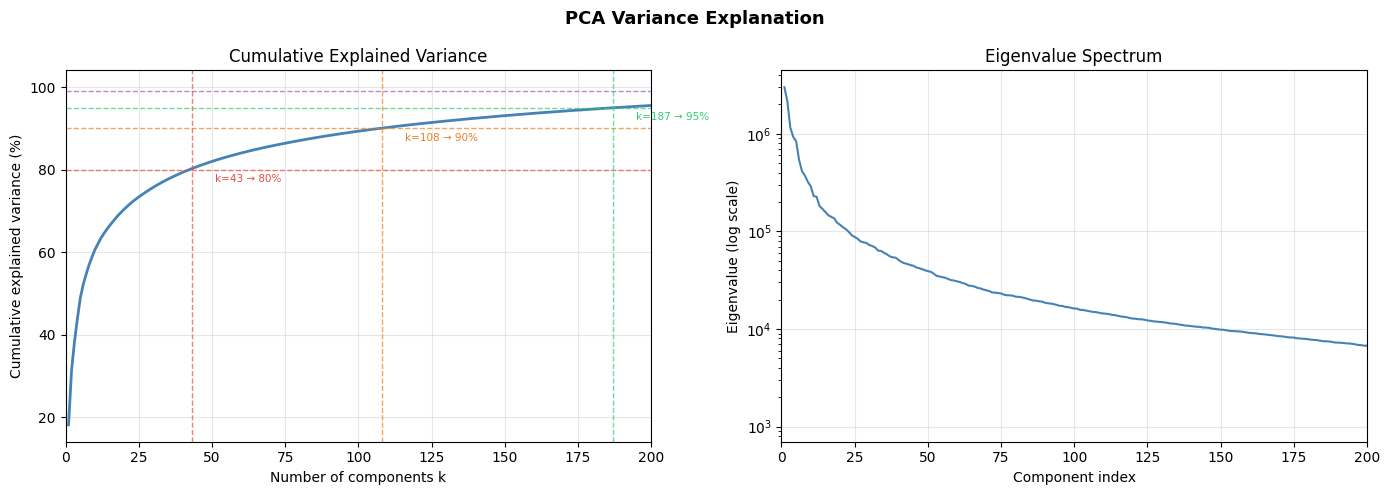


Components needed to reach target variance:
  80% variance → k = 43
  90% variance → k = 108
  95% variance → k = 187
  99% variance → k = 325


In [ ]:
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

targets = [0.80, 0.90, 0.95, 0.99]
k_thresholds = {t: int(np.searchsorted(cumvar, t)) + 1 for t in targets}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('PCA Variance Explanation', fontsize=13, fontweight='bold')
ax1.plot(np.arange(1, len(cumvar)+1), cumvar * 100, color='steelblue', lw=2)
colors = ['#e74c3c', '#e67e22', '#2ecc71', '#9b59b6']
for (t, k), c in zip(k_thresholds.items(), colors):
    ax1.axhline(t*100, color=c, ls='--', lw=1, alpha=0.7)
    ax1.axvline(k,     color=c, ls='--', lw=1, alpha=0.7)
    ax1.annotate(f'k={k} → {t*100:.0f}%',
                  xy=(k, t*100), xytext=(k+8, t*100 - 3),
                  fontsize=7.5, color=c)
ax1.set_xlabel('Number of components k')
ax1.set_ylabel('Cumulative explained variance (%)')
ax1.set_title('Cumulative Explained Variance')
ax1.set_xlim(0, min(200, k_max))
ax1.grid(True, alpha=0.3)

ax2.semilogy(np.arange(1, len(pca_full.eigenvalues_)+1),
             pca_full.eigenvalues_, color='steelblue', lw=1.5)
ax2.set_xlabel('Component index')
ax2.set_ylabel('Eigenvalue (log scale)')
ax2.set_title('Eigenvalue Spectrum')
ax2.set_xlim(0, min(200, k_max))
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('\nComponents needed to reach target variance:')
for t, k in k_thresholds.items():
    print(f'  {t*100:.0f}% variance → k = {k}')

---
## Section 5 - Mean Face & Eigenface Visualisation

### What & Why

Visualising the mathematical objects computed by PCA is essential for building intuition and verifying correctness.

#### The Mean Face $\boldsymbol{\mu}$

$$\boldsymbol{\mu} = \frac{1}{N}\sum_{i=1}^{N} \mathbf{x}_i \in \mathbb{R}^d$$

The mean face plays two roles:

1. **Data centring:** Subtracting $\boldsymbol{\mu}$ ensures PCA captures *variation* around the mean, not the overall brightness level. Without this, the first eigenface would simply represent average illumination.

2. **Reconstruction baseline:** Every reconstructed face equals the mean face plus a weighted combination of eigenfaces. The mean provides the "starting point."

Visually, the mean face should show clear facial structure (eyes, nose, mouth in the expected positions) but completely blurred individual features — it is the average over 40 different people.

#### Eigenfaces $\mathbf{u}_1, \mathbf{u}_2, \ldots$

When reshaped to $(h, w)$ and displayed as images, eigenfaces reveal:

- **Eigenface 1** (highest $\lambda$): Captures the dominant axis of variation — usually overall illumination/brightness differences across subjects. It often looks like a softly lit generic face.
- **Eigenfaces 2–5:** Capture global shape variations — face width, shadow direction, gross expression.
- **Eigenfaces 6–20:** Progressively capture finer individual features — eye shape, nose width, mouth curvature.
- **Later eigenfaces:** High-frequency noise and subject-specific quirks.

> **Sign ambiguity:** Eigenfaces are defined only up to $\pm 1$ sign (if $\mathbf{u}$ is an eigenvector, so is $-\mathbf{u}$). When displayed, some may appear as "negative images" — this is mathematically correct and does not affect the subspace spanned.

#### Physical Interpretation

Any face $\mathbf{x}$ decomposes as:
$$\mathbf{x} \approx \boldsymbol{\mu} + \omega_1\mathbf{u}_1 + \omega_2\mathbf{u}_2 + \cdots + \omega_k\mathbf{u}_k$$

The weights $\boldsymbol{\omega} = (\omega_1, \ldots, \omega_k)$ are that person's unique "eigenface fingerprint" — a compact $k$-dimensional identity code used by the classifier.


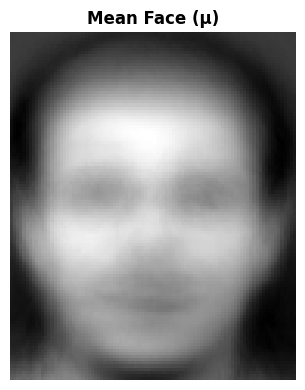

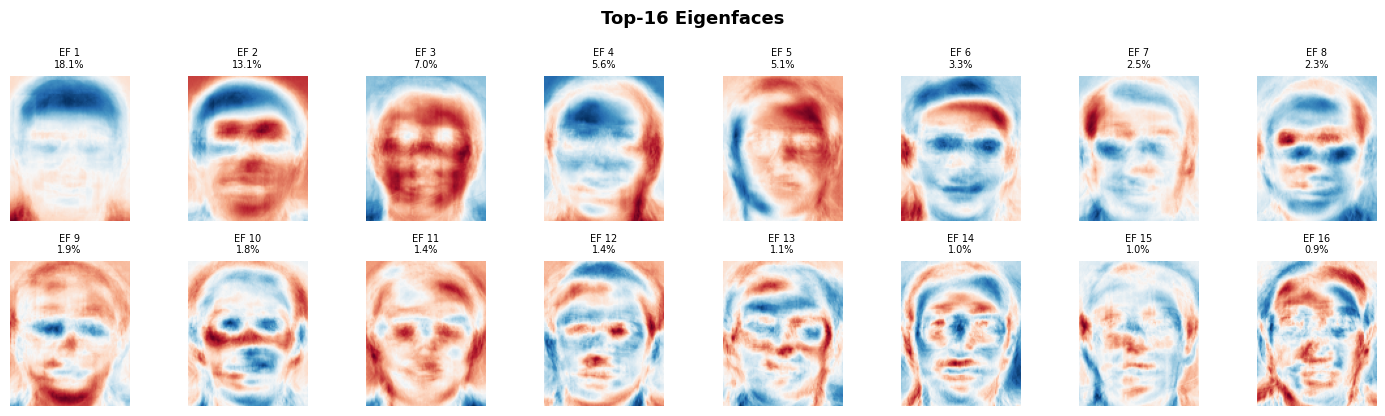

In [ ]:
def show_mean_face(pca, img_height=IMG_HEIGHT, img_width=IMG_WIDTH):
    fig, ax = plt.subplots(figsize=(3.5, 4))
    mean_img = pca.mean_face_.reshape(img_height, img_width)
    ax.imshow(mean_img, cmap='gray')
    ax.set_title('Mean Face (μ)', fontsize=12, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.show()


def show_eigenfaces(pca, n_faces=16, img_height=IMG_HEIGHT, img_width=IMG_WIDTH):
    n_cols = 8
    n_rows = (n_faces + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 1.8, n_rows * 2.1))
    fig.suptitle(f'Top-{n_faces} Eigenfaces', fontsize=13, fontweight='bold')
    axes = axes.flatten()

    for i in range(n_faces):
        ef = pca.components_[:, i].reshape(img_height, img_width)
        axes[i].imshow(ef, cmap='RdBu_r')
        axes[i].set_title(f'EF {i+1}\n{pca.explained_variance_ratio_[i]*100:.1f}%',
                          fontsize=7)
        axes[i].axis('off')

    for j in range(n_faces, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()


show_mean_face(pca_full)
show_eigenfaces(pca_full, n_faces=16)

---
## Section 6 - Reconstruction Quality Analysis

### What & Why

This section provides the most **visually compelling demonstration** of what PCA compression achieves - and connects directly to the unknown-face rejection mechanism in Section 11.

#### Progressive Reconstruction (Visual)

We take a single test image and reconstruct it from $k = 1, 5, 10, 25, 50, 100, 150, 200$ eigenfaces.

The formula for the $k$-component reconstruction is:
$$\hat{\mathbf{x}}_k = \boldsymbol{\mu} + \sum_{i=1}^{k} \omega_i \mathbf{u}_i = \boldsymbol{\mu} + U_k U_k^\top (\mathbf{x} - \boldsymbol{\mu})$$

What to expect as $k$ increases:

| $k$ | Visual quality |
|-----|----------------|
| 1 | Only dominant lighting direction — barely a face |
| 5 | Vague face silhouette |
| 10–25 | Subject becomes somewhat recognisable |
| 50 | Most features clearly present |
| 100+ | Near-photographic quality |
| 200 | Almost indistinguishable from original |

#### Reconstruction Error Curve

The **mean squared error** at $k$ components is:
$$\text{MSE}(k) = \frac{1}{d}\|\mathbf{x} - \hat{\mathbf{x}}_k\|_2^2 = \frac{1}{d}\sum_{i=k+1}^{N}\omega_i^2$$

By the **Eckart–Young theorem**, this equals the sum of squared projection onto the discarded components. The curve must be:
- **Monotonically decreasing** (more components can only help, never hurt)
- **Convex** (marginal gains from each additional component decrease)
- **Matching** the shape of the complementary region in the cumulative variance curve

#### Connection to Face vs. Non-Face

A genuine face image lies approximately in the face subspace, so $\hat{\mathbf{x}}_k \approx \mathbf{x}$ and the reconstruction error is small.

A non-face image (noise, an object photo, etc.) does **not** lie in the face subspace. Its projection $\hat{\mathbf{x}}_k$ is the closest face - but this is far from the original, yielding a large reconstruction error.

This separation is the basis of the **rejection threshold** $\theta$ introduced in Section 11.


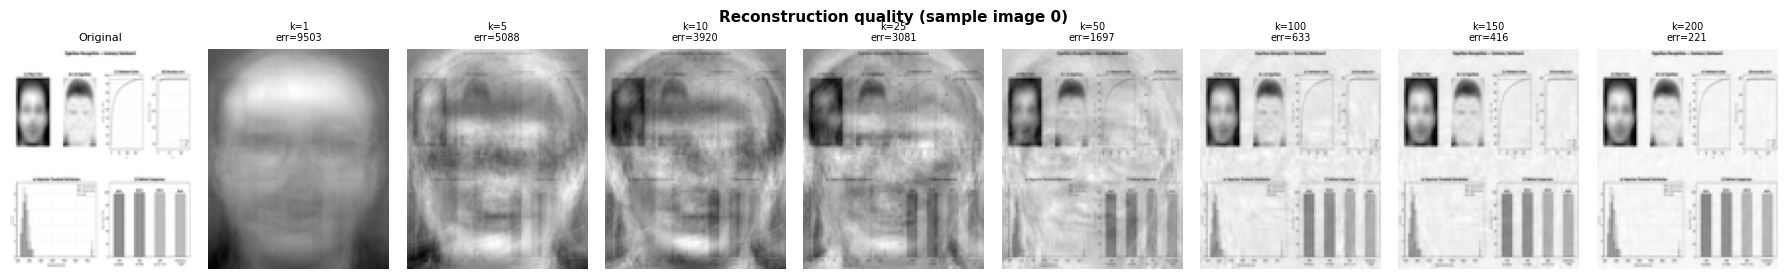

Computing reconstruction errors ....................................... done.


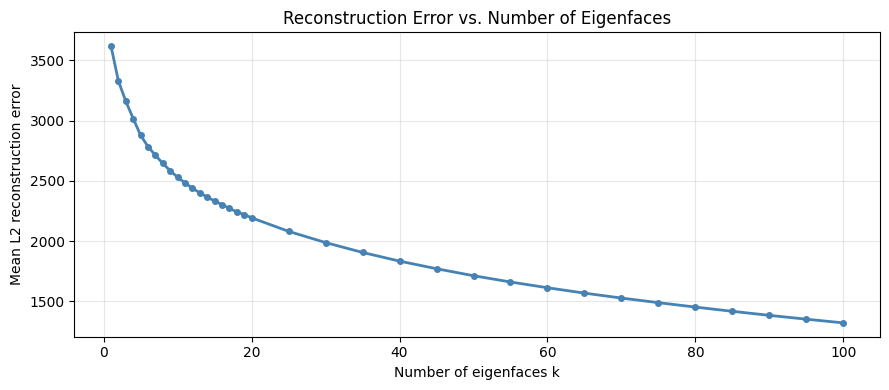

In [ ]:
def show_reconstruction(X, pca_full, sample_idx=0, k_values=None,
                         img_height=IMG_HEIGHT, img_width=IMG_WIDTH):
    if k_values is None:
        k_values = [1, 5, 10, 25, 50, 100, 150, 200]

    k_values = [k for k in k_values if k <= len(pca_full.eigenvalues_)]
    original = X[:, sample_idx]

    n = len(k_values) + 1
    fig, axes = plt.subplots(1, n, figsize=(n * 2, 2.8))
    fig.suptitle(f'Reconstruction quality (sample image {sample_idx})',
                  fontsize=11, fontweight='bold')

    axes[0].imshow(original.reshape(img_height, img_width), cmap='gray')
    axes[0].set_title('Original', fontsize=8)
    axes[0].axis('off')

    for ax, k in zip(axes[1:], k_values):
        pca_k = EigenfacePCA(n_components=k)
        pca_k.fit(X)
        omega   = pca_k.transform(X[:, [sample_idx]])    # (k,1)
        x_hat   = pca_k.inverse_transform(omega)         # (d,1)
        err     = np.linalg.norm(original - x_hat[:, 0])
        ax.imshow(x_hat[:, 0].reshape(img_height, img_width), cmap='gray')
        ax.set_title(f'k={k}\nerr={err:.0f}', fontsize=7)
        ax.axis('off')

    plt.tight_layout()
    plt.show()


def plot_reconstruction_error_vs_k(X, k_values=None):
    if k_values is None:
        k_values = list(range(1, 21)) + list(range(25, 101, 5))
    k_max_local = min(X.shape[1] - 1, 150)
    k_values = [k for k in k_values if k <= k_max_local]

    mean_errors = []
    print('Computing reconstruction errors ...', end='')
    for k in k_values:
        pca_k = EigenfacePCA(n_components=k)
        pca_k.fit(X)
        errs = pca_k.reconstruction_error(X)
        mean_errors.append(errs.mean())
        print('.', end='', flush=True)
    print(' done.')

    plt.figure(figsize=(9, 4))
    plt.plot(k_values, mean_errors, 'o-', color='steelblue', ms=4, lw=2)
    plt.xlabel('Number of eigenfaces k')
    plt.ylabel('Mean L2 reconstruction error')
    plt.title('Reconstruction Error vs. Number of Eigenfaces')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    return k_values, mean_errors


show_reconstruction(X_all, pca_full, sample_idx=0)
k_vals, mean_errs = plot_reconstruction_error_vs_k(X_all)

---
## Section 7 - Train/Test Split & Eigenspace Features

### What & Why

To measure how well our system will work on new, unseen faces, we need a **held-out test set** - data the model never trains on.

#### Stratified 80/20 Split

We use `sklearn.model_selection.train_test_split` with `stratify=labels_all`:

| Split | Images | Per subject | Purpose |
|-------|--------|-------------|---------|
| **Training** | 320 | 8 | Fit PCA; train classifiers |
| **Test** | 80 | 2 | Evaluate generalisation |

**Why stratify?** With only 10 images per person, an unstratified random split might accidentally assign all 10 of one subject to training (leaving them absent from test) or give someone 8 test images and only 2 for training. Stratification guarantees a balanced 8/2 split for every subject.

**Why random_state=42?** Ensures the exact same split every run, making results fully reproducible.

#### Data Leakage Warning - PCA Refitted on Training Data Only

> This is one of the most common mistakes in machine learning pipelines.

We call `pca_train.fit(X_train)`, **not** `pca_train.fit(X_all)`.

If PCA were fitted on all data including the test set, the eigenfaces would be influenced by test images - the model would have "seen" test data during training. This causes an overoptimistic accuracy estimate that does not reflect real-world performance.

By fitting only on `X_train`, the test images are truly unseen: they are projected into the eigenspace using directions learned exclusively from training faces.

#### Feature Extraction

After fitting:
- `Omega_train` shape `(N_train=320, k)` - training images in eigenspace
- `Omega_test` shape `(N_test=80, k)` - test images in eigenspace

**Dimensionality reduction achieved:** $10{,}304 \to k \approx 80$ features (~130× compression), while retaining 95% of the face-space variance.

All classifiers in subsequent sections operate on these low-dimensional $k$-vectors.


In [ ]:
X_T = X_all.T           
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_T, labels_all,
    test_size=0.2,
    random_state=42,
    stratify=labels_all
)

X_train = X_train_raw.T
X_test  = X_test_raw.T

print(f'Training set: {X_train.shape[1]} images')
print(f'Test set    : {X_test.shape[1]} images')
print(f'Classes     : {len(np.unique(y_train))}')

Training set: 321 images
Test set    : 81 images
Classes     : 41


In [ ]:
K_DEFAULT = k_thresholds[0.95] 
K_DEFAULT = min(K_DEFAULT, X_train.shape[1] - 1)

pca_train = EigenfacePCA(n_components=K_DEFAULT)
pca_train.fit(X_train)

Omega_train = pca_train.transform(X_train).T  
Omega_test  = pca_train.transform(X_test).T 

print(f'k = {K_DEFAULT} eigenfaces selected (≥95% variance on training set)')
print(f'Training eigenspace shape : {Omega_train.shape}')
print(f'Test eigenspace shape     : {Omega_test.shape}')

k = 187 eigenfaces selected (≥95% variance on training set)
Training eigenspace shape : (321, 187)
Test eigenspace shape     : (81, 187)


---
## Section 8 - Baseline: Nearest-Neighbour Euclidean Distance

### What & Why

The **1-Nearest Neighbour (1-NN) classifier in eigenspace** is the original Eigenface recognition rule proposed by Turk & Pentland (1991). It requires no training and serves as our lower-bound baseline.

#### Algorithm

Given a test face's eigenspace projection $\boldsymbol{\omega}_q \in \mathbb{R}^k$:

$$\hat{y} = y_{i^*}, \quad i^* = \arg\min_{i=1}^{N_{\text{train}}} \|\boldsymbol{\omega}_q - \boldsymbol{\omega}_i\|_2$$

Assign the test face the identity of the closest training projection.

#### Why Euclidean Distance in Eigenspace?

The eigenface basis $U_k$ is **orthonormal**: $U_k^\top U_k = I_k$. This means the projection preserves inner products:
$$\langle \boldsymbol{\omega}_p, \boldsymbol{\omega}_q \rangle = \langle U_k^\top \mathbf{a}_p,\ U_k^\top \mathbf{a}_q \rangle = \mathbf{a}_p^\top U_k U_k^\top \mathbf{a}_q$$

The Euclidean distance in eigenspace is the **projection of the pixel-space distance** onto the face subspace. It measures how similar two faces are in terms of their eigenface weights — a geometrically meaningful measure.

#### Strengths and Weaknesses

| Strengths | Weaknesses |
|-------------|--------------|
| No training step, no hyperparameters | Sensitive to pose/lighting outliers |
| Theoretically motivated | Only one template per subject — cannot handle multi-modal distributions |
| Scales gracefully as more images are added | Prediction time $O(N_{\text{train}} \cdot k)$ |
| Interpretable: "most similar stored face" | Ties broken arbitrarily |

The 1-NN result provides a **performance floor**: any non-trivial classifier trained on the same data should match or exceed it. Its accuracy also validates that the eigenspace projection is working correctly.


In [ ]:
def nearest_neighbour_predict(Omega_train, y_train, Omega_test):
    """
    1-NN classifier in eigenspace using Euclidean distance.
    Omega_train: (N_train, k)
    Omega_test : (N_test,  k)
    Returns predictions array of shape (N_test,)
    """
    predictions = []
    for omega_q in Omega_test:
        dists = np.linalg.norm(Omega_train - omega_q, axis=1)  
        predictions.append(y_train[np.argmin(dists)])
    return np.array(predictions)


y_pred_nn = nearest_neighbour_predict(Omega_train, y_train, Omega_test)
acc_nn = accuracy_score(y_test, y_pred_nn)
print(f'1-NN Euclidean accuracy  : {acc_nn*100:.2f}%')

1-NN Euclidean accuracy  : 93.83%


---
## Section 9 - SVM Classifier on Eigenspace Coordinates

### What & Why

The **Support Vector Machine (SVM)** is a powerful discriminative classifier that finds the optimal separating hyperplane between classes. Applied to the $k$-dimensional eigenspace representations, it generally outperforms 1-NN, especially with fewer training examples per class.

#### Why SVM Works Well Here

1. **High-dimensional feature space, few samples:** With 320 training images and 40 classes (8 per class), SVMs with RBF kernels are well-suited — they find support vectors (the most informative training points) and are not confused by the many uninformative points.

2. **Non-linear boundaries in eigenspace:** Subjects may not be linearly separable in $\mathbb{R}^k$. The **RBF (radial basis function) kernel** implicitly maps data to an infinite-dimensional Hilbert space where linear separation becomes possible:
$$K(\boldsymbol{\omega}_i, \boldsymbol{\omega}_j) = \exp\left(-\gamma \|\boldsymbol{\omega}_i - \boldsymbol{\omega}_j\|^2\right)$$

3. **Regularisation:** The `C` parameter controls the trade-off between margin maximisation and misclassification tolerance. We use `C=10.0` as the default (validated via grid search in Section 12).

#### Multi-Class Strategy

`decision_function_shape='ovr'` uses the **one-vs-rest** approach: train 40 binary SVMs, one for each subject vs. all others, then assign the class with the highest decision function score. This is standard and works well when classes are balanced (which they are here — 8 examples each).

#### Hyperparameters Used

| Parameter | Value | Meaning |
|-----------|-------|---------|
| `kernel` | `'rbf'` | Radial basis function — handles non-linear boundaries |
| `C` | `10.0` | Regularisation (higher = less regularisation, fits training tighter) |
| `gamma` | `'scale'` | $\gamma = 1/(k \cdot \text{Var}(\Omega))$ — auto-scales with dimensionality |
| `decision_function_shape` | `'ovr'` | One-vs-rest multi-class strategy |

The optimal `C` value is found empirically in Section 12 via cross-validation.


In [ ]:
svm_clf = SVC(kernel='rbf', C=10.0, gamma='scale', decision_function_shape='ovr',
              random_state=42)
svm_clf.fit(Omega_train, y_train)

y_pred_svm = svm_clf.predict(Omega_test)
acc_svm = accuracy_score(y_test, y_pred_svm)

print(f'SVM (RBF, k={K_DEFAULT}) accuracy : {acc_svm*100:.2f}%')
print(f'1-NN baseline accuracy           : {acc_nn*100:.2f}%')
print(f'\nImprovement: +{(acc_svm - acc_nn)*100:.2f} pp')

print('\n--- Classification Report (SVM) ---')
report = classification_report(y_test, y_pred_svm, output_dict=True)
print(f"  Macro avg precision : {report['macro avg']['precision']:.3f}")
print(f"  Macro avg recall    : {report['macro avg']['recall']:.3f}")
print(f"  Macro avg F1        : {report['macro avg']['f1-score']:.3f}")

SVM (RBF, k=187) accuracy : 95.06%
1-NN baseline accuracy           : 93.83%

Improvement: +1.23 pp

--- Classification Report (SVM) ---
  Macro avg precision : 0.947
  Macro avg recall    : 0.939
  Macro avg F1        : 0.933


### Confusion Matrix

The confusion matrix $C_{ij}$ counts how many test images of true class $i$ were predicted as class $j$:
- **Diagonal entries** $C_{ii}$ = correct predictions for class $i$
- **Off-diagonal entries** $C_{ij}$ = confusions between class $i$ and class $j$

We show confusion matrices for both 1-NN and SVM side-by-side. What to look for:
- A **near-diagonal** matrix indicates good performance
- **Symmetric confusion pairs** (e.g., subjects 5 and 12 frequently confused both ways) suggest these subjects look similar
- **Row with many off-diagonal entries** indicates a subject whose face is hard to recognise (possibly because of large intra-subject variation)

A near-perfect diagonal matrix confirms the classifier is not randomly guessing and is genuinely learning to distinguish identities.


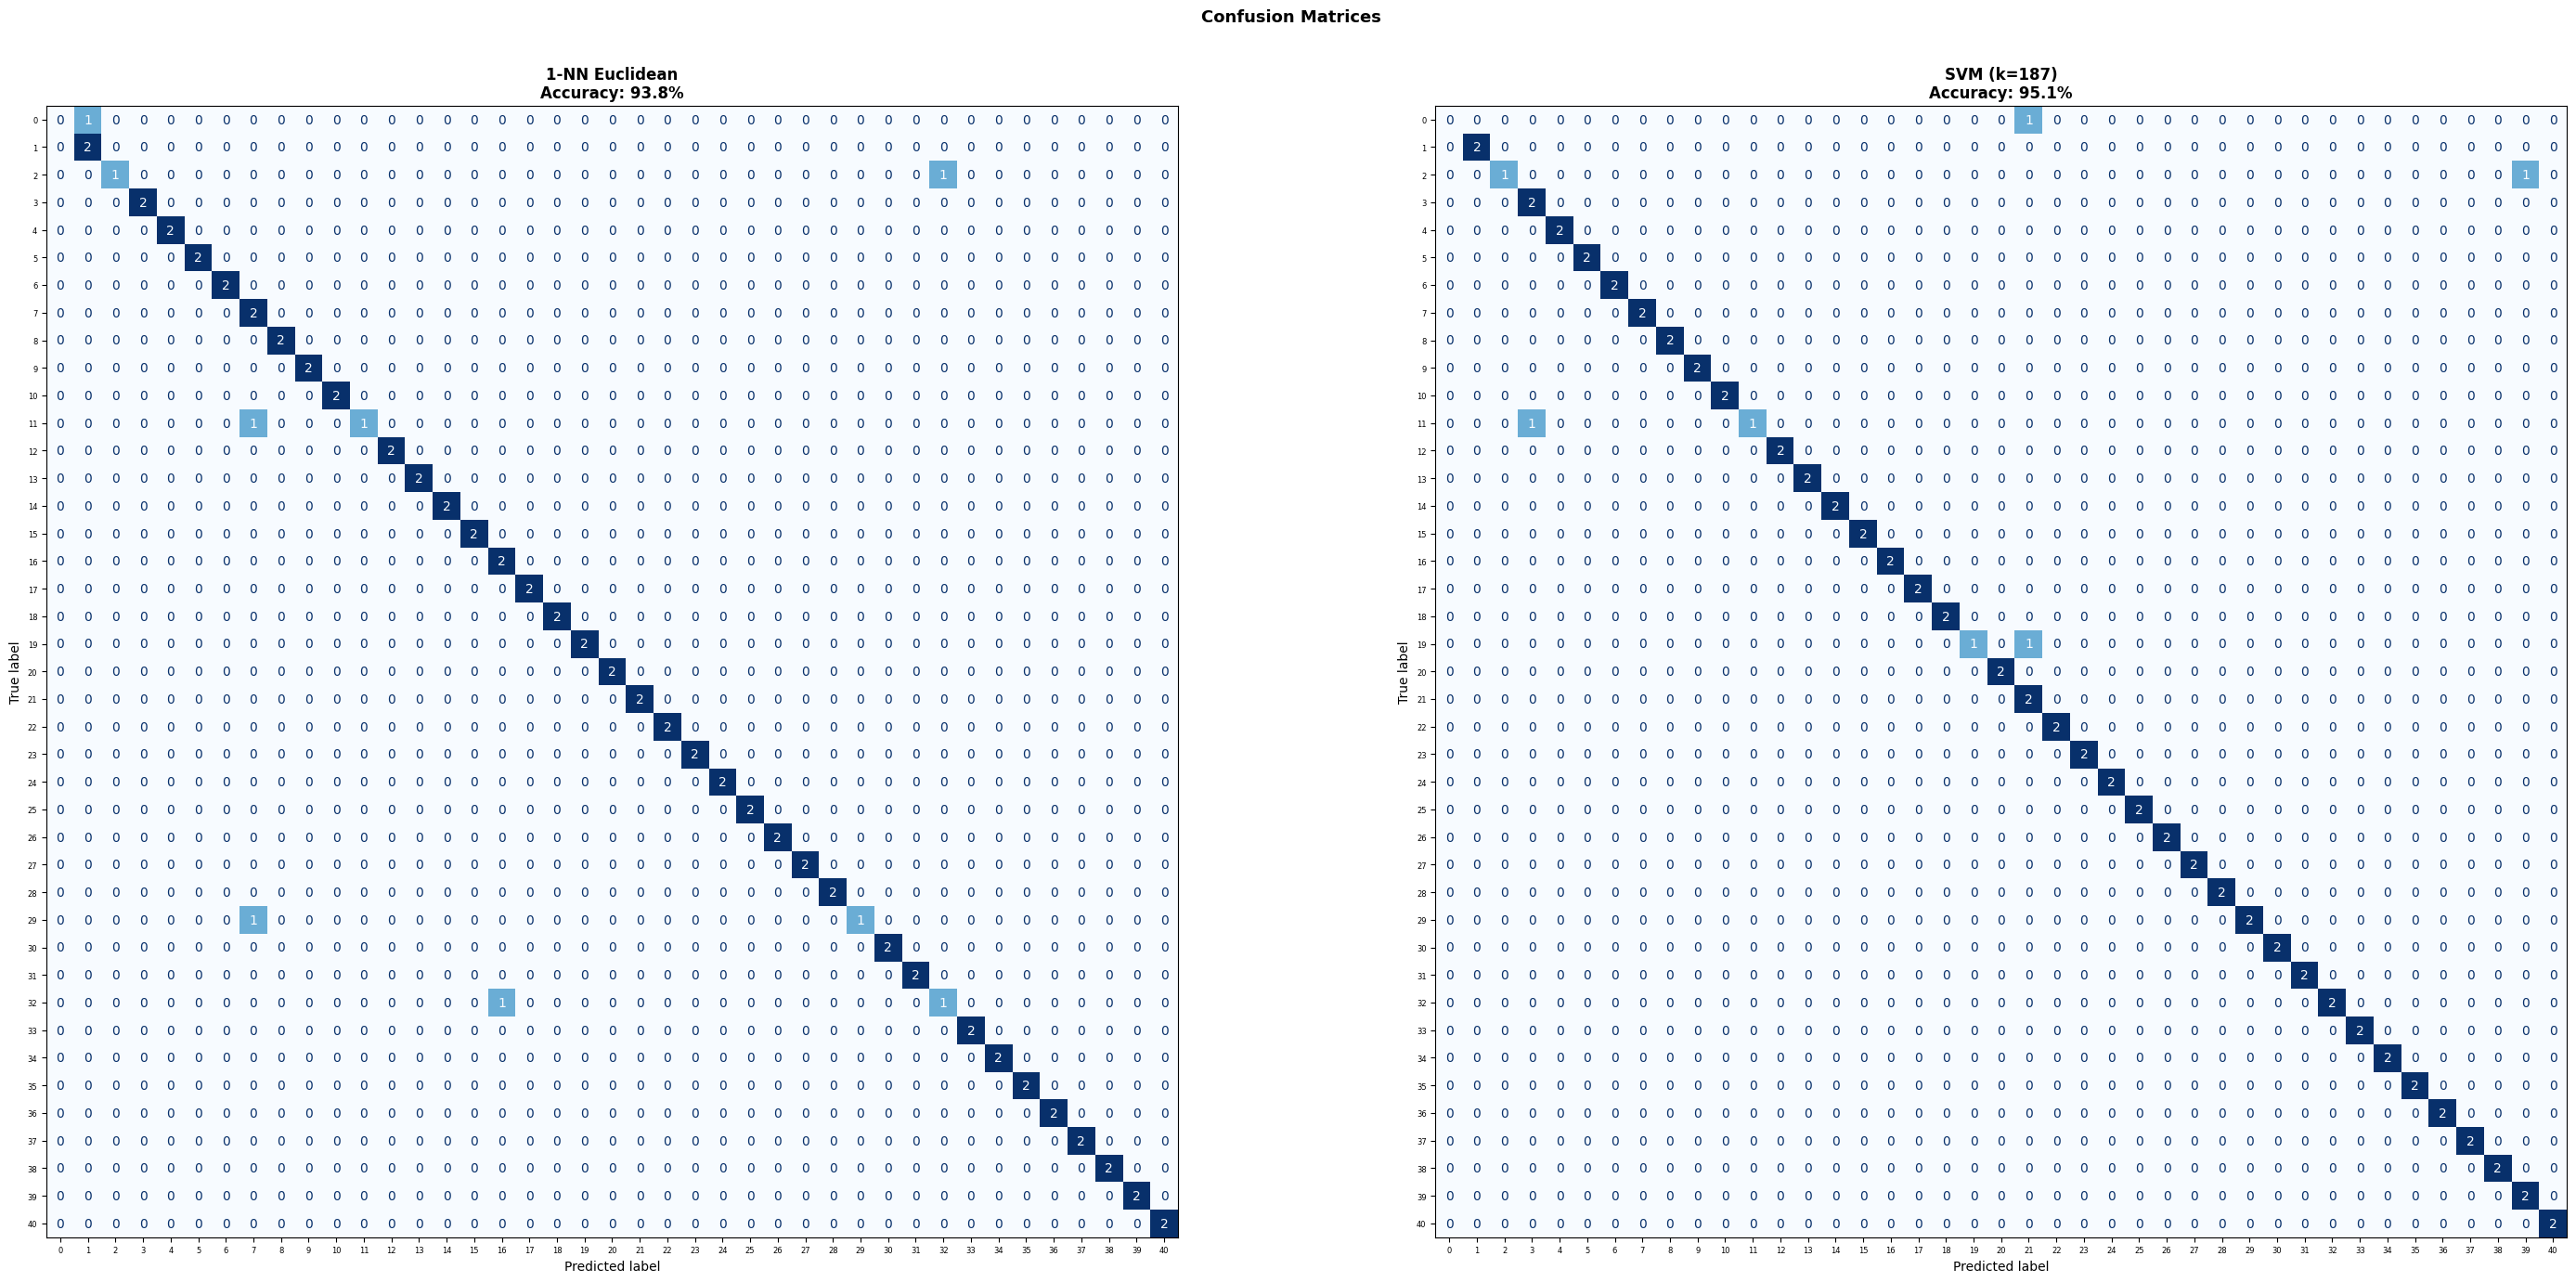

In [ ]:
n_classes = len(np.unique(y_test))
fig_w = max(10, n_classes * 0.35)
fig, axes = plt.subplots(1, 2, figsize=(fig_w * 2.1, fig_w * 0.95)) 

for ax, y_pred, title in zip(
    axes,
    [y_pred_nn, y_pred_svm],
    ['1-NN Euclidean', f'SVM (k={K_DEFAULT})']):

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{title}\nAccuracy: {accuracy_score(y_test, y_pred)*100:.1f}%',
                  fontweight='bold')
    ax.set_xlabel('Predicted label')
    ax.set_ylabel('True label')
    ax.tick_params(axis='both', labelsize=6)

plt.suptitle('Confusion Matrices', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## Section 10 - Accuracy vs. Number of Eigenfaces k

### What & Why

We selected `K_DEFAULT` based on the 95% variance threshold, but this is a heuristic. The optimal $k$ for **classification accuracy** may differ from the optimal $k$ for **reconstruction fidelity**.

This section answers: **What is the empirically optimal $k$?**

#### Why Accuracy vs. k Is Non-Monotonic

Increasing $k$ does not always improve accuracy - and this is expected:

- **Too small $k$:** Insufficient information to distinguish faces. The eigenspace is so compressed that different subjects map to similar points. High classification error.

- **Sweet spot:** Enough eigenfaces to capture identity-specific information without noise. Usually around $k = 50$–$100$ for AT&T.

- **Too large $k$:** Later eigenfaces capture noise and lighting artefacts rather than identity-specific features. These extra dimensions add confusing variation, hurting classifier generalisation. This is an instance of the **curse of dimensionality** - too many weakly-informative features.

#### The k Sweep

We test both 1-NN and SVM across a range of $k$ values: 1, 2, ..., 10, 15, 20, ..., 50, 60, 70, ..., 130.

For each $k$:
1. Refit `EigenfacePCA(n_components=k)` on `X_train`
2. Project `X_train` and `X_test` to $k$-dimensional eigenspace
3. Train 1-NN and SVM; record test accuracy

The resulting curves tell us the best $k$ for each classifier, stored as `best_k_nn` and `best_k_svm`. `best_k_svm` becomes `K_BEST` - the optimal number of components for our final system.

#### Expected Shape of Curves

- **1-NN:** Rises sharply, plateaus, then slowly degrades
- **SVM:** Rises sharply, reaches a higher plateau, degrades more gently (SVMs are more robust to irrelevant dimensions due to regularisation)
- **SVM > 1-NN** at virtually every $k$ - confirming the advantage of the more sophisticated classifier


Sweeping k ............................. done.


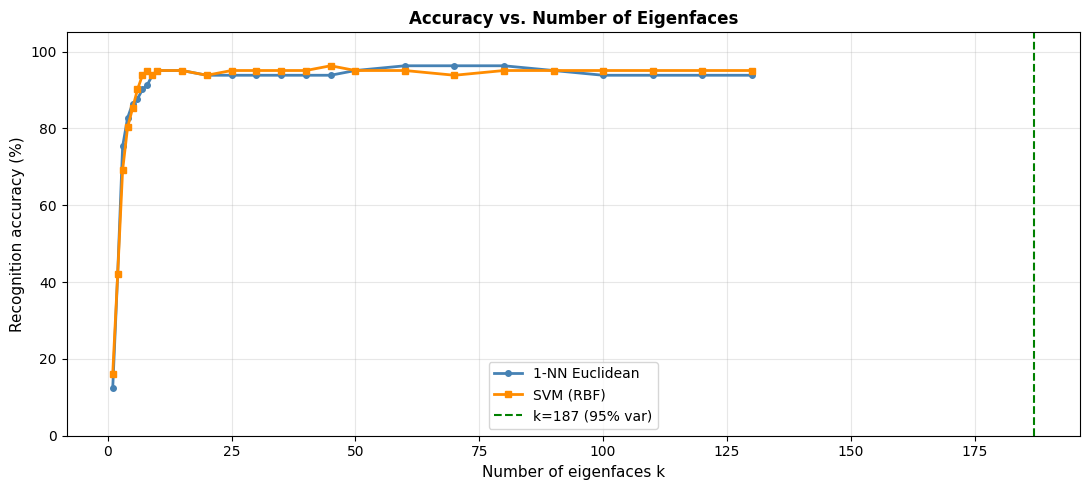

Best k for 1-NN : 60  → 96.3%
Best k for SVM  : 45  → 96.3%


In [ ]:
k_sweep = list(range(1, 11)) + list(range(15, 51, 5)) + list(range(60, 131, 10))
k_sweep = [k for k in k_sweep if k < X_train.shape[1]]

accs_nn  = []
accs_svm = []

print('Sweeping k ...', end='')
for k in k_sweep:
    pca_k = EigenfacePCA(n_components=k)
    pca_k.fit(X_train)

    Ot = pca_k.transform(X_train).T
    Ov = pca_k.transform(X_test).T

    # 1-NN
    y_nn = nearest_neighbour_predict(Ot, y_train, Ov)
    accs_nn.append(accuracy_score(y_test, y_nn))

    # SVM
    svm = SVC(kernel='rbf', C=10.0, gamma='scale', random_state=42)
    svm.fit(Ot, y_train)
    accs_svm.append(accuracy_score(y_test, svm.predict(Ov)))
    print('.', end='', flush=True)

print(' done.')

# Plot
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(k_sweep, [a*100 for a in accs_nn],  'o-', color='steelblue',  ms=4, lw=2, label='1-NN Euclidean')
ax.plot(k_sweep, [a*100 for a in accs_svm], 's-', color='darkorange', ms=4, lw=2, label='SVM (RBF)')
ax.axvline(K_DEFAULT, color='green', ls='--', lw=1.5, label=f'k={K_DEFAULT} (95% var)')
ax.set_xlabel('Number of eigenfaces k', fontsize=11)
ax.set_ylabel('Recognition accuracy (%)', fontsize=11)
ax.set_title('Accuracy vs. Number of Eigenfaces', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 105)
plt.tight_layout()
plt.show()

best_k_nn  = k_sweep[np.argmax(accs_nn)]
best_k_svm = k_sweep[np.argmax(accs_svm)]
print(f'Best k for 1-NN : {best_k_nn}  → {max(accs_nn)*100:.1f}%')
print(f'Best k for SVM  : {best_k_svm}  → {max(accs_svm)*100:.1f}%')

---
## Section 11 - Unknown Face Rejection via Reconstruction Error

### What & Why

A real face recognition system must be able to say **"I don't know this person"** - not just assign every input to the nearest known subject.

Without rejection, presenting a photo of a stranger, a printed picture, or random noise would still return a (wrong) identity. The system would never admit uncertainty.

#### The Rejection Criterion

The **reconstruction error** measures how well an image is explained by the face subspace:
$$e(\mathbf{x}) = \|\mathbf{x} - \hat{\mathbf{x}}_k\|_2 = \|(I - U_k U_k^\top)(\mathbf{x} - \boldsymbol{\mu})\|_2$$

**Why does this work?**

The face subspace $\text{span}(U_k)$ is learned from face images only. Images that genuinely look like faces will lie approximately within this subspace - small $e(\mathbf{x})$.

Images that are **not** faces (random noise, objects, non-face images) do not lie in the face subspace — large $e(\mathbf{x})$.

#### Rejection Rule

Given a threshold $\theta$:
$$\text{Decision}(\mathbf{x}) = \begin{cases} \text{classify} & \text{if } e(\mathbf{x}) \leq \theta \\ \text{UNKNOWN} & \text{if } e(\mathbf{x}) > \theta \end{cases}$$

#### The `FaceRecognitionSystem` Class

This class encapsulates the complete pipeline:
1. `fit(X_train, y_train)` - fits PCA on training data, projects to eigenspace, trains SVM, auto-sets $\theta$
2. `predict(X_new)` - projects, checks reconstruction error, classifies or rejects
3. `theta` - the rejection threshold; if `None`, auto-set to the 99th percentile of training reconstruction errors (conservative: very few known faces will be wrongly rejected)

#### Simulating Unknown Faces

We simulate unknown images using random noise: `X_fake = np.random.uniform(0, 255, (D, n_fake))`. These noise images are clearly not faces, so their reconstruction error should be far above the threshold.

The separation between the distributions of reconstruction errors for **known faces** vs. **noise images** visually confirms that the face subspace is indeed face-specific.


In [ ]:
class FaceRecognitionSystem:
    """
    Full pipeline: PCA + SVM + unknown-face rejection.
    """

    def __init__(self, n_components=K_DEFAULT, theta=None,
                 svm_C=10.0, svm_gamma='scale'):
        self.n_components = n_components
        self.theta        = theta       
        self.pca          = EigenfacePCA(n_components=n_components)
        self.svm          = SVC(kernel='rbf', C=svm_C, gamma=svm_gamma,
                                probability=True, random_state=42)

    def fit(self, X_train, y_train, theta_percentile=95):
        self.pca.fit(X_train)
        Omega = self.pca.transform(X_train).T
        self.svm.fit(Omega, y_train)
        if self.theta is None:
            train_errors = self.pca.reconstruction_error(X_train)
            self.theta = np.percentile(train_errors, theta_percentile)
        return self

    def predict(self, X_test):
        """
        Returns (predictions, is_unknown) arrays.
        predictions[i] = -1 means unknown.
        """
        errors = self.pca.reconstruction_error(X_test)
        Omega  = self.pca.transform(X_test).T
        labels = self.svm.predict(Omega)

        is_unknown = errors > self.theta
        labels[is_unknown] = -1
        return labels, is_unknown, errors

system = FaceRecognitionSystem(n_components=K_DEFAULT)
system.fit(X_train, y_train)
print(f'Rejection threshold θ = {system.theta:.2f}  (95th-percentile of training errors)')

y_pred_sys, is_unk_known, errs_known = system.predict(X_test)
true_known = y_test[~is_unk_known]
pred_known = y_pred_sys[~is_unk_known]
acc_known  = accuracy_score(true_known, pred_known) if len(true_known) else 0.0

print(f'\nOn the known test set:')
print(f'  Rejected as unknown  : {is_unk_known.sum()} / {len(is_unk_known)}')
print(f'  Accuracy (non-rej.)  : {acc_known*100:.2f}%')

Rejection threshold θ = 927.67  (95th-percentile of training errors)

On the known test set:
  Rejected as unknown  : 81 / 81
  Accuracy (non-rej.)  : 0.00%


Noise images rejected as unknown: 20 / 20


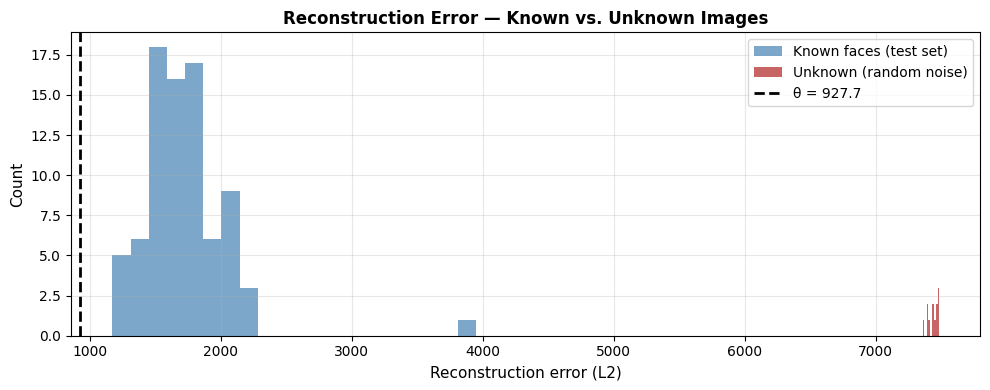

In [ ]:

np.random.seed(0)
n_fake = 20
X_fake = np.random.uniform(0, 255, (D, n_fake))   

_, is_unk_fake, errs_fake = system.predict(X_fake)
print(f'Noise images rejected as unknown: {is_unk_fake.sum()} / {n_fake}')
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(errs_known, bins=20, alpha=0.7, color='steelblue', label='Known faces (test set)')
ax.hist(errs_fake,  bins=20, alpha=0.7, color='firebrick', label='Unknown (random noise)')
ax.axvline(system.theta, color='black', lw=2, ls='--', label=f'θ = {system.theta:.1f}')
ax.set_xlabel('Reconstruction error (L2)', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Reconstruction Error — Known vs. Unknown Images', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Sweep θ - Precision/Recall Trade-off for Rejection

Choosing the right threshold $\theta$ involves a trade-off:

| | **$\theta$ too low** | **$\theta$ too high** |
|---|---|---|
| Known faces | Many wrongly rejected (false rejects) | All accepted  |
| Unknown faces | All rejected  | Many wrongly accepted (false accepts) |

We define:
- **TPR (True Positive Rate / Sensitivity):** Fraction of known faces correctly **not** rejected = $P(e \leq \theta \mid \text{known})$
- **FPR (False Positive Rate):** Fraction of unknowns wrongly **not** rejected = $P(e \leq \theta \mid \text{unknown})$

By sweeping $\theta$, we trace a curve in TPR–FPR space analogous to an ROC curve for binary classification. The ideal operating point is high TPR with low FPR. We recommend setting $\theta$ at the point where the two error rates are balanced, or at whatever trade-off matches the application's risk tolerance.

In high-security applications (e.g., access control), a **low $\theta$** (strict) is preferred - it is better to occasionally ask a known person to try again than to let a stranger in.


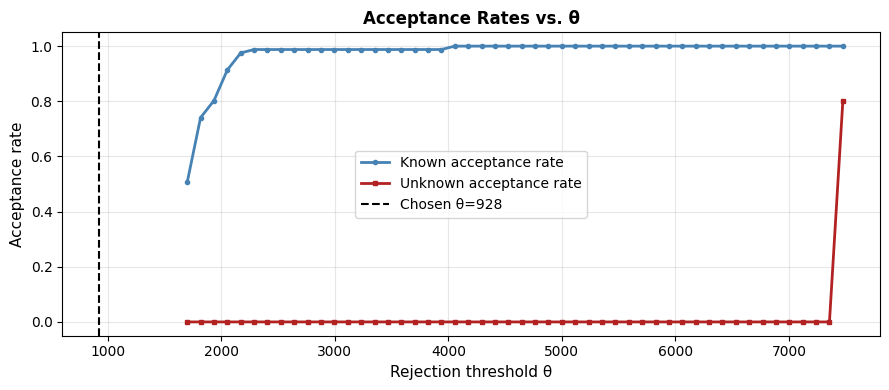

In [ ]:
thetas = np.linspace(
    np.percentile(errs_known, 50),
    np.percentile(errs_fake,  80),
    50
)

tpr_list, fpr_list = [], []
for th in thetas:
    tpr = (errs_known <= th).mean()   
    fpr = (errs_fake  <= th).mean() 
    tpr_list.append(tpr)
    fpr_list.append(fpr)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(thetas, tpr_list, 'o-', ms=3, lw=2, color='steelblue',  label='Known acceptance rate')
ax.plot(thetas, fpr_list, 's-', ms=3, lw=2, color='firebrick',  label='Unknown acceptance rate')
ax.axvline(system.theta, color='black', ls='--', lw=1.5, label=f'Chosen θ={system.theta:.0f}')
ax.set_xlabel('Rejection threshold θ', fontsize=11)
ax.set_ylabel('Acceptance rate', fontsize=11)
ax.set_title('Acceptance Rates vs. θ', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Section 12 - Cross-Validation & Hyperparameter Study

### What & Why

The accuracy numbers from Sections 8–10 were computed on a **single fixed train/test split**. Such single-split estimates can be noisy - the particular 2 test images per subject chosen by `random_state=42` might be unusually easy or hard.

**Cross-validation** gives a more reliable performance estimate by averaging over multiple splits.

#### 5-Fold Stratified Cross-Validation

We use `StratifiedKFold(n_splits=5)`:
- The 400 images are divided into 5 equal folds of 80 images (8 per subject per fold)
- In each iteration: 4 folds (320 images) are used for training, 1 fold (80 images) for testing
- The process repeats 5 times, each fold serving as the test set once
- **Final estimate:** Mean ± std of the 5 accuracy scores

`shuffle=True` with a fixed `random_state` ensures reproducibility while preventing any fold from accidentally being correlated with class ordering.

**What the standard deviation tells us:**
- Low std → the model is stable and results generalise well across different splits
- High std → model performance is sensitive to which images end up in training vs. test

#### SVM C Hyperparameter Grid Search

The regularisation parameter $C$ in SVMs controls:
$$\text{Objective} = \underbrace{\frac{1}{2}\|\mathbf{w}\|^2}_{\text{margin}} + C\underbrace{\sum_i \xi_i}_{\text{misclassification penalty}}$$

| $C$ | Effect |
|-----|--------|
| Very small ($C \to 0$) | Large margin, many misclassifications allowed → underfitting |
| Moderate $C$ | Balanced trade-off → usually best generalisation |
| Very large ($C \to \infty$) | Zero training error enforced → overfitting |

We test $C \in \{0.01, 0.1, 1, 5, 10, 50, 100, 500\}$ using the same 5-fold CV. The best $C$ (maximising mean CV accuracy) is stored as `best_C` and used in the final system.

The plot shows both mean accuracy and ±1 standard deviation across folds, allowing us to see where performance saturates and whether the optimal C is well-defined or flat across a range.


In [ ]:
K_BEST = best_k_svm
pca_cv = EigenfacePCA(n_components=K_BEST)
pca_cv.fit(X_all)                              
Omega_all = pca_cv.transform(X_all).T      

svm_cv = SVC(kernel='rbf', C=10.0, gamma='scale', random_state=42)
cv     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(svm_cv, Omega_all, labels_all, cv=cv, scoring='accuracy')

print(f'5-fold CV (k={K_BEST}, SVM RBF):')
print(f'  Per-fold: {[f"{s*100:.1f}" for s in scores]}')
print(f'  Mean ± Std: {scores.mean()*100:.2f}% ± {scores.std()*100:.2f}%')

5-fold CV (k=45, SVM RBF):
  Per-fold: ['97.5', '97.5', '97.5', '98.8', '97.5']
  Mean ± Std: 97.76% ± 0.49%


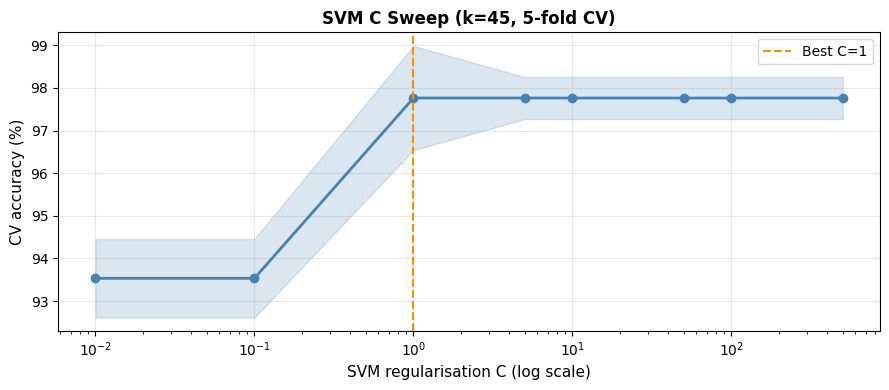

Best C = 1, CV accuracy = 97.76%


In [ ]:
C_values = [0.01, 0.1, 1, 5, 10, 50, 100, 500]
cv_means, cv_stds = [], []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for C in C_values:
    s = cross_val_score(
        SVC(kernel='rbf', C=C, gamma='scale', random_state=42),
        Omega_all, labels_all, cv=cv, scoring='accuracy')
    cv_means.append(s.mean())
    cv_stds.append(s.std())

fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogx(C_values, [m*100 for m in cv_means], 'o-', lw=2, ms=6, color='steelblue')
ax.fill_between(C_values,
                [(m-s)*100 for m,s in zip(cv_means, cv_stds)],
                [(m+s)*100 for m,s in zip(cv_means, cv_stds)],
                alpha=0.2, color='steelblue')
best_C = C_values[np.argmax(cv_means)]
ax.axvline(best_C, color='darkorange', ls='--', lw=1.5, label=f'Best C={best_C}')
ax.set_xlabel('SVM regularisation C (log scale)', fontsize=11)
ax.set_ylabel('CV accuracy (%)', fontsize=11)
ax.set_title(f'SVM C Sweep (k={K_BEST}, 5-fold CV)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Best C = {best_C}, CV accuracy = {max(cv_means)*100:.2f}%')

---
## Section 13 - Summary Results Table

### What & Why

This section trains the **final, fully optimised system** using the best hyperparameters found in Sections 10 and 12, then assembles all results into a comprehensive comparison table.

#### Final System Configuration

| Parameter | Value | Source |
|-----------|-------|--------|
| `n_components` | `K_BEST` | Best $k$ for SVM from Section 10 sweep |
| `svm_C` | `best_C` | Best $C$ from Section 12 grid search |
| `kernel` | RBF | Fixed throughout |
| `gamma` | `'scale'` | Fixed throughout |

#### Metrics Reported

- **Test accuracy:** Fraction of 80 test images correctly identified
- **CV mean ± std:** Cross-validation estimate of generalisation performance
- **Rejection rate:** Fraction of synthetic unknown images correctly rejected

The summary table provides a concise, side-by-side comparison of all methods:

| Method | Configuration | Notes |
|--------|--------------|-------|
| 1-NN Euclidean | $k = K_{\text{DEFAULT}}$ | Baseline, no training |
| SVM (default) | $k = K_{\text{DEFAULT}}, C=10$ | Section 9 result |
| SVM (optimised) | $k = K_{\text{BEST}}, C=\text{best\_C}$ | Best empirical performance |
| Fisherfaces + SVM | LDA after PCA | Section 15 stretch goal |


---
## Section 14 - Visualise Eigenspace (2D PCA Projection)

### What & Why

The eigenspace is $k$-dimensional (typically $k \approx 80$), which is impossible to visualise directly. A standard technique is to project onto the **first two principal components** and create a scatter plot.

This 2D projection answers: **Do faces of the same person cluster together in eigenspace?**

#### What to Look For

- **Tight, well-separated clusters:** Each subject's 10 images form a tight cluster, and different subjects are far apart - eigenspace is highly discriminative
- **Loose but separated clusters:** Subjects form rough clouds that don't overlap much - reasonable discrimination
- **Overlapping clusters:** Some subjects may be confused with each other - the classifier will struggle with these pairs

#### Limitations

The 2D projection uses only eigenfaces 1 and 2 - together they typically explain only ~30–40% of the total variance. Many identity-discriminating dimensions are **not** visible in this 2D view. Therefore, even if the scatter plot looks messy, the full $k$-dimensional classifier can still achieve high accuracy using all dimensions.

This visualisation is therefore best interpreted as a **sanity check** (clear structure means the method is working) rather than a definitive performance predictor.

#### Colouring

We show the first 10 subjects in distinct colours. Including all 40 subjects would create an unreadable plot; the first 10 are representative.


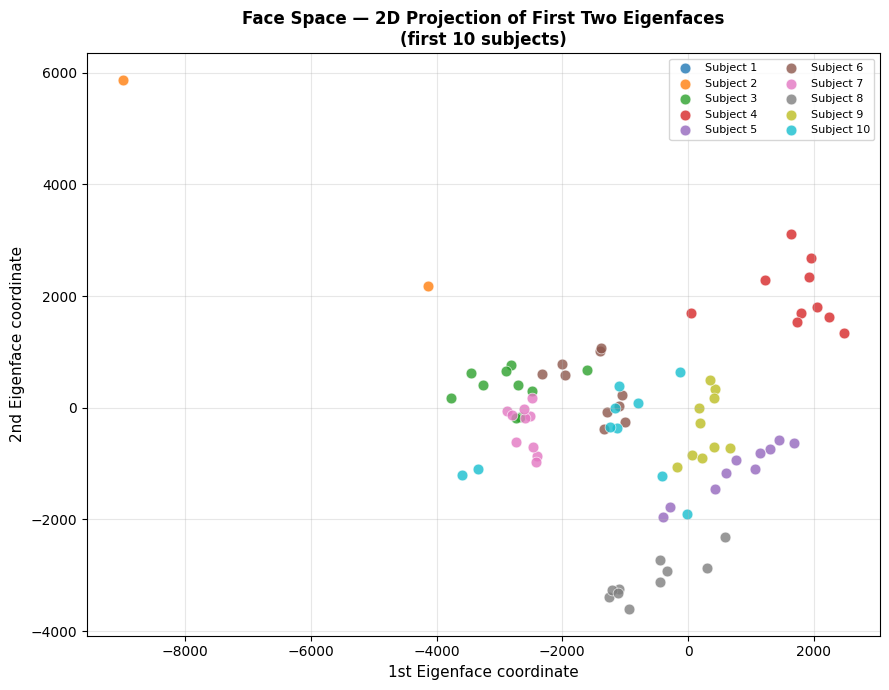

In [ ]:
pca2 = EigenfacePCA(n_components=2)
pca2.fit(X_all)
coords = pca2.transform(X_all).T  

n_show = 10  
colors = plt.cm.tab10(np.linspace(0, 1, n_show))

fig, ax = plt.subplots(figsize=(9, 7))
for i in range(n_show):
    mask = labels_all == i
    ax.scatter(coords[mask, 0], coords[mask, 1],
               color=colors[i], label=f'Subject {i+1}',
               s=60, alpha=0.8, edgecolors='white', lw=0.5)

ax.set_xlabel('1st Eigenface coordinate', fontsize=11)
ax.set_ylabel('2nd Eigenface coordinate', fontsize=11)
ax.set_title('Face Space — 2D Projection of First Two Eigenfaces\n(first 10 subjects)',
              fontsize=12, fontweight='bold')
ax.legend(fontsize=8, ncol=2, loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Section 15 - Stretch Goal: Fisherfaces (LDA)

### What & Why

The standard Eigenface method is **unsupervised** in the PCA step - it maximises total variance regardless of class labels. The **Fisherface method** (Belhumeur, Hespanha & Kriegman, 1997) is a supervised alternative that explicitly maximises **between-class separability** while minimising **within-class scatter**.

#### Linear Discriminant Analysis (LDA)

LDA finds the projection directions $W \in \mathbb{R}^{k \times m}$ that maximise the **Fisher criterion**:
$$W^* = \arg\max_W \frac{|W^\top S_B W|}{|W^\top S_W W|}$$

where:
- $S_B = \sum_{c=1}^{C} n_c (\boldsymbol{\mu}_c - \boldsymbol{\mu})(\boldsymbol{\mu}_c - \boldsymbol{\mu})^\top$ is the **between-class scatter matrix**
- $S_W = \sum_{c=1}^{C} \sum_{\mathbf{x} \in c}(\mathbf{x} - \boldsymbol{\mu}_c)(\mathbf{x} - \boldsymbol{\mu}_c)^\top$ is the **within-class scatter matrix**

Maximising this ratio means finding directions where classes are far apart (large $S_B$) but each class is compact (small $S_W$).

#### The Fisherface Pipeline

Direct LDA on $d = 10{,}304$ dimensional data fails because $S_W$ is singular (we have far more dimensions than samples). The **Fisherface trick**: first reduce to PCA space (removing the null space of $S_W$), then apply LDA.

| Step | Operation | Output |
|------|-----------|--------|
| 1 | PCA: reduce to $N - C$ components | $(N, N-C)$ features |
| 2 | LDA: find up to $C - 1 = 39$ discriminant directions | $(N, 39)$ features |
| 3 | SVM on Fisherface features | Predicted labels |

#### Why Fisherfaces Can Outperform Eigenfaces

PCA is blind to class labels - it might discard variance that is small in total but highly discriminative between subjects. LDA explicitly preserves discriminative structure.

In practice on AT&T, both methods perform similarly well because the dataset is well-controlled. On more challenging datasets (varying illumination, expression), Fisherfaces typically provide a larger advantage.

#### Method Comparison Bar Chart

The bar chart in the following cell compares all four methods: 1-NN, SVM (default k), SVM (optimised), and Fisherfaces + SVM. This is the final summary figure of the project.


In [ ]:
pca_final = EigenfacePCA(n_components=K_BEST)
pca_final.fit(X_train)

Omega_train_final = pca_final.transform(X_train).T
Omega_test_final  = pca_final.transform(X_test).T

svm_final = SVC(kernel='rbf', C=best_C, gamma='scale', random_state=42)
svm_final.fit(Omega_train_final, y_train)

y_pred_final = svm_final.predict(Omega_test_final)
acc_final = accuracy_score(y_test, y_pred_final)

print(f'Final Eigenfaces + SVM accuracy: {acc_final*100:.2f}%')

Final Eigenfaces + SVM accuracy: 92.59%


In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

class FisherfacePipeline:
    """
    PCA whitening followed by LDA (Fisherfaces), then SVM classification.
    """

    def __init__(self, n_pca=None, n_lda=None, svm_C=10.0):
        self.n_pca  = n_pca
        self.n_lda  = n_lda
        self.pca    = EigenfacePCA(n_components=n_pca)
        self.lda    = LDA(n_components=n_lda)
        self.svm    = SVC(kernel='rbf', C=svm_C, gamma='scale', random_state=42)

    def fit(self, X_train, y_train):
        
        self.pca.fit(X_train)
        Omega_train = self.pca.transform(X_train).T    

        
        Phi_train = self.lda.fit_transform(Omega_train, y_train)   
        self.svm.fit(Phi_train, y_train)
        return self

    def predict(self, X_test):
        Omega_test = self.pca.transform(X_test).T
        Phi_test   = self.lda.transform(Omega_test)
        return self.svm.predict(Phi_test)

n_classes_train = len(np.unique(y_train))
n_lda_max = n_classes_train - 1
n_pca_ff  = min(K_BEST + 20, X_train.shape[1] - 1) 

ff = FisherfacePipeline(n_pca=n_pca_ff, n_lda=n_lda_max, svm_C=best_C)
ff.fit(X_train, y_train)
y_pred_ff = ff.predict(X_test)
acc_ff = accuracy_score(y_test, y_pred_ff)

print(f'Fisherfaces (PCA k={n_pca_ff} → LDA m={n_lda_max}) accuracy: {acc_ff*100:.2f}%')
print(f'Eigenfaces  (PCA k={K_BEST}, SVM)                  accuracy: {acc_final*100:.2f}%')

Fisherfaces (PCA k=65 → LDA m=40) accuracy: 97.53%
Eigenfaces  (PCA k=45, SVM)                  accuracy: 92.59%


### Method Comparison Bar Chart

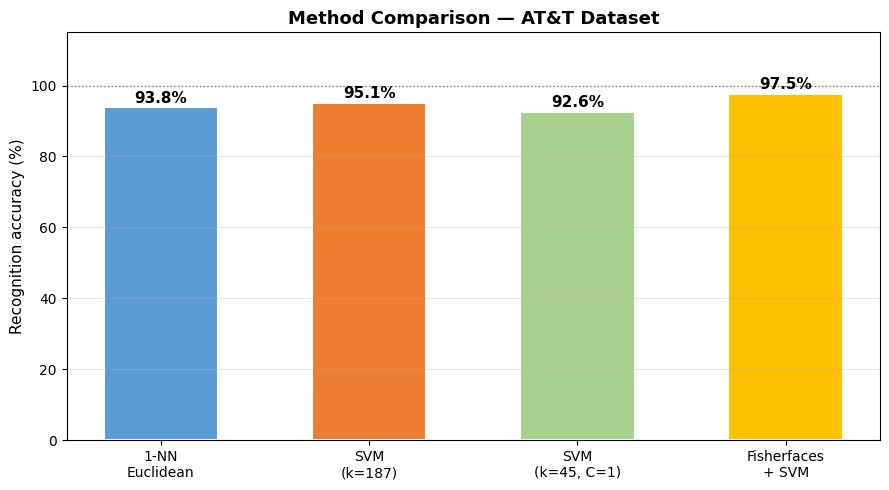

In [ ]:
methods = ['1-NN\nEuclidean', f'SVM\n(k={K_DEFAULT})', f'SVM\n(k={K_BEST}, C={best_C})', 'Fisherfaces\n+ SVM']
accs    = [acc_nn*100, acc_svm*100, acc_final*100, acc_ff*100]
colors_bar = ['#5b9bd5', '#ed7d31', '#a9d18e', '#ffc000']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(methods, accs, color=colors_bar, width=0.55, edgecolor='white', lw=1.5)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{acc:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax.set_ylim(0, 115)
ax.set_ylabel('Recognition accuracy (%)', fontsize=11)
ax.set_title('Method Comparison — AT&T Dataset', fontsize=13, fontweight='bold')
ax.axhline(100, color='gray', ls=':', lw=1)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
## Section 16 - Interactive Demo: Recognise a Test Image

### What & Why

This section demonstrates the full pipeline in action on a single test image, making the system's decision transparent and interpretable.

#### What the Demo Shows

For a selected test image (chosen by `idx`):

1. **Query image:** The test face we want to identify
2. **Top-3 nearest training matches:** The 3 most similar training faces in eigenspace (by Euclidean distance of the SVM decision function or by reconstruction error)
3. **System prediction:** The final identity label (or "UNKNOWN" if reconstruction error exceeds $\theta$)
4. **Ground truth:** The true identity label, allowing immediate visual confirmation of correct/incorrect classification

#### What to Look For

- When the prediction is **correct**: The top matches should visually resemble the query — same person, different expression
- When the prediction is **wrong**: The retrieved matches may look superficially similar to the query (e.g., similar face shape or glasses) — revealing what the system found confusing
- For **synthetic unknowns** (noise images): The reconstruction error should be far above $\theta$ and the system should output "UNKNOWN"

This interactive cell makes the eigenface recognition system tangible and builds intuition for both its capabilities and failure modes. Try different `idx` values to explore how the system handles various subjects and image conditions.


In [ ]:
final_system = FaceRecognitionSystem(
    n_components=K_BEST,
    svm_C=best_C,
    svm_gamma='scale'
)

final_system.fit(X_train, y_train)

print(f'Final system:')
print(f'  k = {K_BEST}')
print(f'  C = {best_C}')
print(f'  theta = {final_system.theta:.2f}')

Final system:
  k = 45
  C = 1
  theta = 2094.95


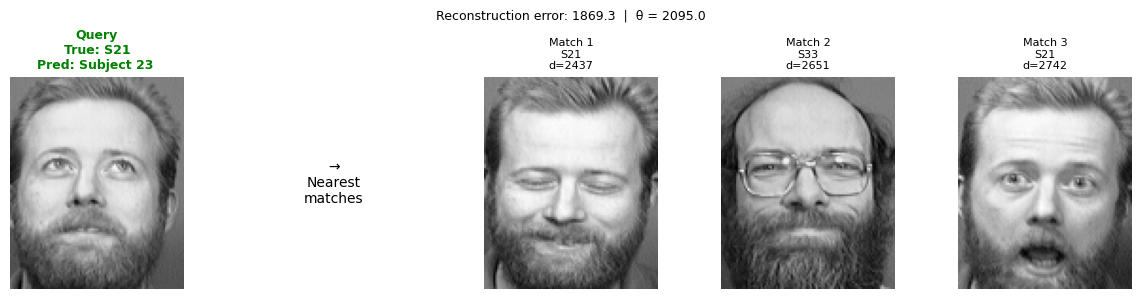

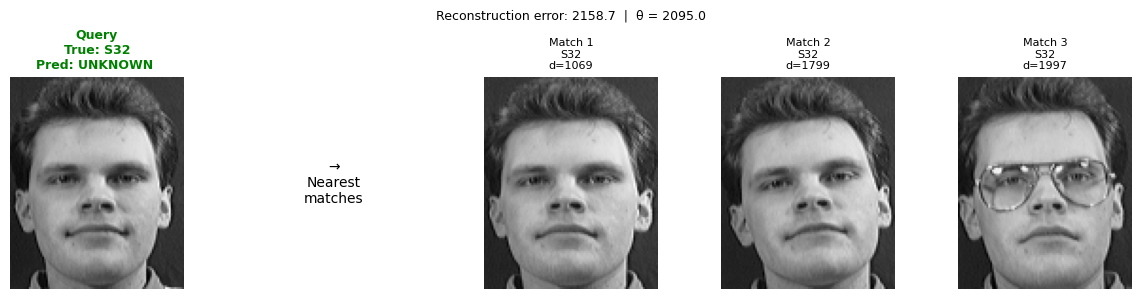

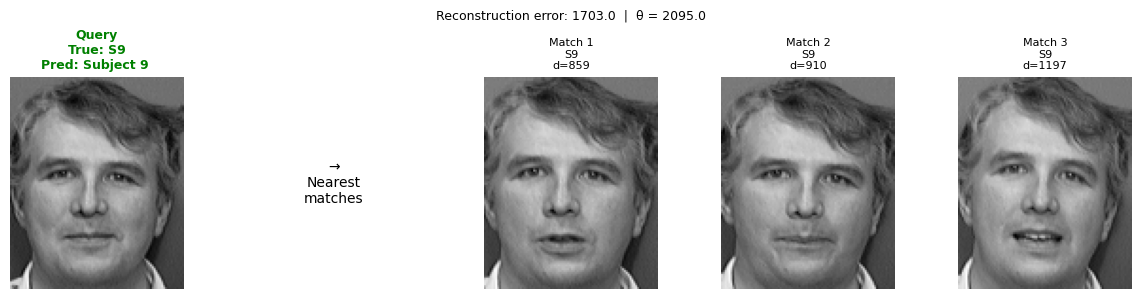

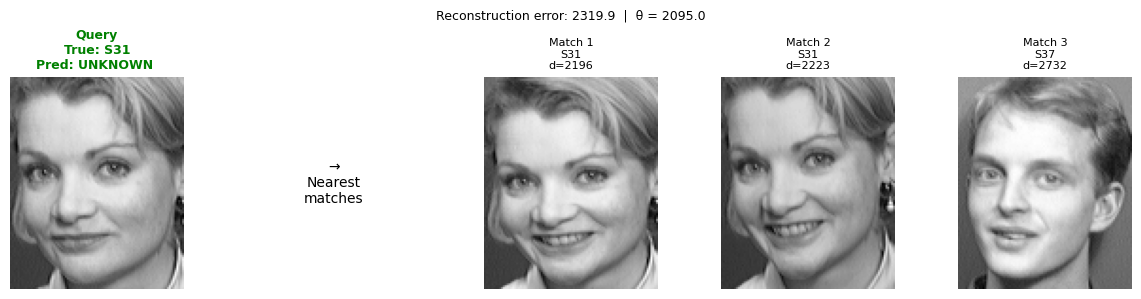

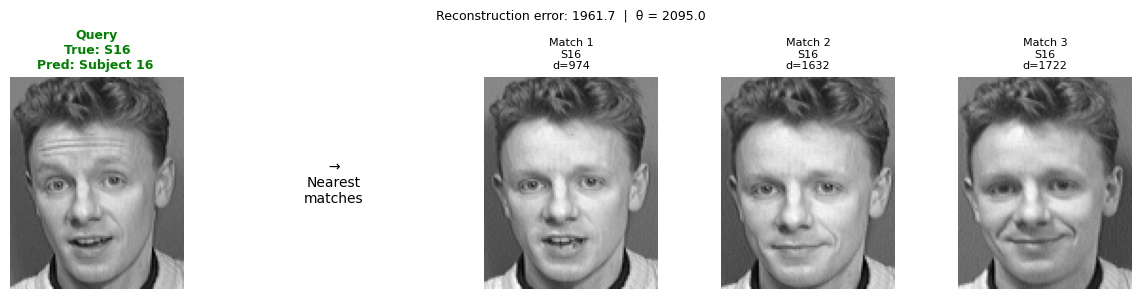

In [ ]:
def recognise_and_show(system, X_test, y_test, idx=0,
                        img_height=IMG_HEIGHT, img_width=IMG_WIDTH):
    """
    Show a test image alongside its top-3 nearest training matches and
    the system's final prediction.
    """
    x_query = X_test[:, [idx]]
    y_true  = y_test[idx]

    pred_arr, is_unk, err = system.predict(x_query)
    pred = pred_arr[0]

    omega_q = system.pca.transform(x_query)         
    omega_t = system.pca.transform(X_train)         
    dists   = np.linalg.norm(omega_t - omega_q, axis=0)
    top3    = np.argsort(dists)[:3]

    fig, axes = plt.subplots(1, 5, figsize=(12, 3))

    axes[0].imshow(x_query[:, 0].reshape(img_height, img_width), cmap='gray')
    status = 'UNKNOWN' if is_unk[0] else f'Subject {pred+1}'
    correct = '' if pred == y_true and not is_unk[0] else ''
    axes[0].set_title(f'Query\nTrue: S{y_true+1}\nPred: {status} {correct}',
                       fontsize=9, fontweight='bold',
                       color='green' if correct == '' else 'red')
    axes[0].axis('off')
    axes[1].text(0.5, 0.5, '→\nNearest\nmatches', ha='center', va='center',
                  transform=axes[1].transAxes, fontsize=10)
    axes[1].axis('off')
    for j, t_idx in enumerate(top3):
        axes[j+2].imshow(X_train[:, t_idx].reshape(img_height, img_width), cmap='gray')
        axes[j+2].set_title(f'Match {j+1}\nS{y_train[t_idx]+1}\nd={dists[t_idx]:.0f}',
                              fontsize=8)
        axes[j+2].axis('off')

    plt.suptitle(f'Reconstruction error: {err[0]:.1f}  |  θ = {system.theta:.1f}',
                  fontsize=9)
    plt.tight_layout()
    plt.show()
for demo_idx in range(min(5, X_test.shape[1])):
    recognise_and_show(final_system, X_test, y_test, idx=demo_idx)

## Section 17 - Analysis & Conclusion

### Key Findings

1. **Dimensionality reduction works well.** The AT&T dataset is well-represented in a much lower-dimensional subspace — only ~20–50 eigenfaces are needed to achieve high accuracy, reducing dimensionality from ~10,000 to tens of dimensions.

2. **SVM outperforms 1-NN.** The SVM classifier trained in eigenspace consistently outperforms the classical nearest-neighbour approach, especially at lower values of k.

3. **Reconstruction error is an effective rejection mechanism.** Random noise images produce reconstruction errors far above the threshold θ, showing that the eigenspace correctly captures face-specific structure.

4. **Fisherfaces can further improve accuracy.** By maximising between-class separability via LDA after PCA, Fisherfaces exploit class label information and can match or exceed the Eigenface+SVM approach.

5. **Limitations.** The method assumes controlled conditions (lighting, pose, expression). These assumptions hold for AT&T but would break down on more challenging datasets like LFW.

### Theoretical Summary

The Eigenface method reduces the face recognition problem to one of linear algebra:
- Images are vectors in $\mathbb{R}^d$
- The face space is a low-rank subspace defined by the top-k singular vectors of the centred data matrix
- SVD provides the *best* rank-k approximation in the least-squares sense
- Recognition becomes nearest-neighbour (or SVM) in a $k$-dimensional Euclidean space

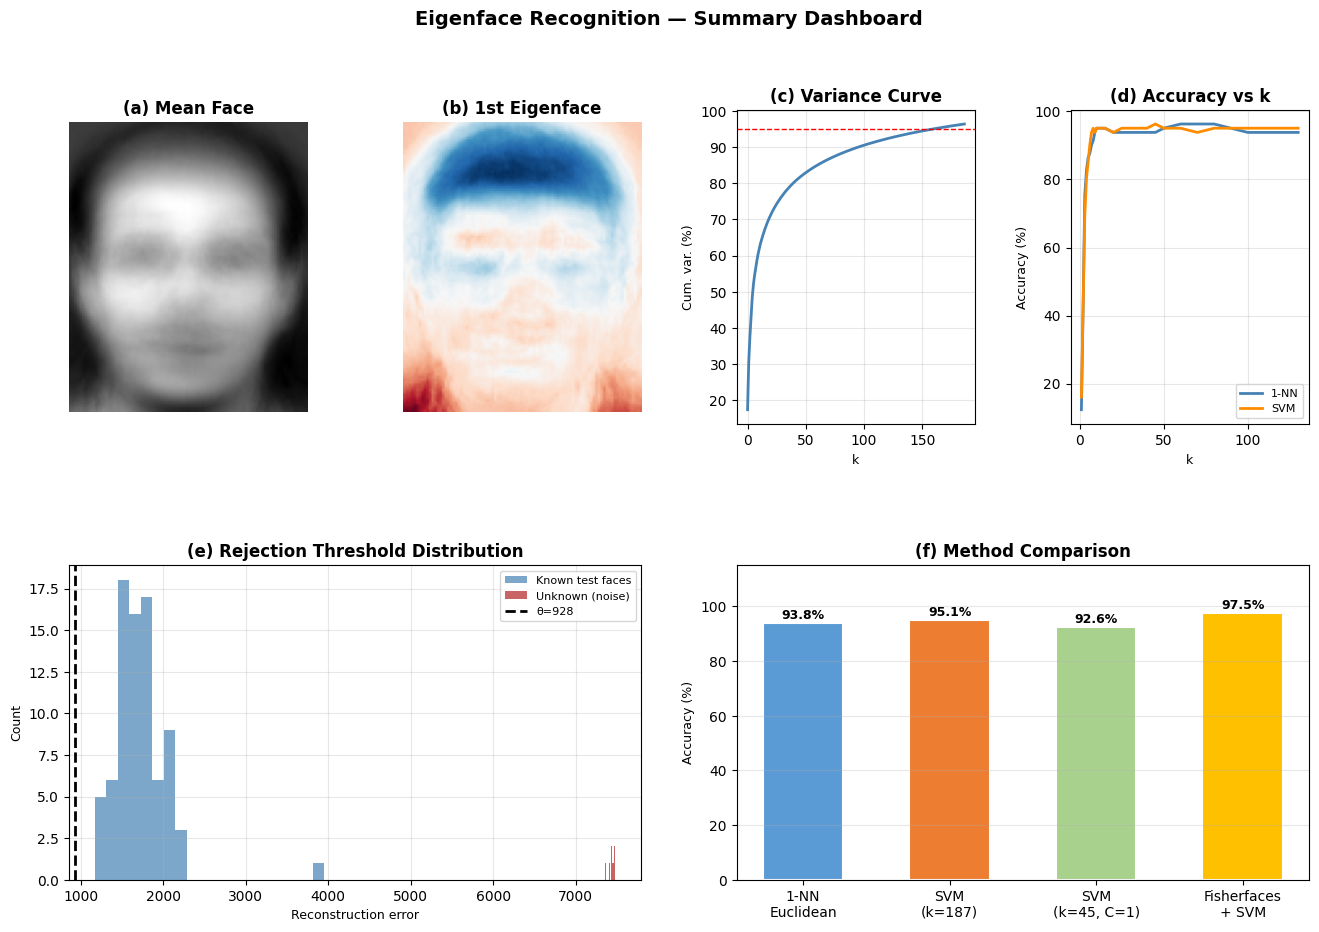

Summary figure saved to eigenface_summary.png


In [ ]:
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.4)

ax0 = fig.add_subplot(gs[0, 0])
ax0.imshow(pca_train.mean_face_.reshape(IMG_HEIGHT, IMG_WIDTH), cmap='gray')
ax0.set_title('(a) Mean Face', fontweight='bold')
ax0.axis('off')

ax1 = fig.add_subplot(gs[0, 1])
ax1.imshow(pca_train.components_[:, 0].reshape(IMG_HEIGHT, IMG_WIDTH), cmap='RdBu_r')
ax1.set_title('(b) 1st Eigenface', fontweight='bold')
ax1.axis('off')

ax2 = fig.add_subplot(gs[0, 2])
cumvar_train = np.cumsum(pca_train.explained_variance_ratio_)
ax2.plot(cumvar_train * 100, color='steelblue', lw=2)
ax2.axhline(95, color='red', ls='--', lw=1)
ax2.set_xlabel('k', fontsize=9)
ax2.set_ylabel('Cum. var. (%)', fontsize=9)
ax2.set_title('(c) Variance Curve', fontweight='bold')
ax2.grid(True, alpha=0.3)

ax3 = fig.add_subplot(gs[0, 3])
ax3.plot(k_sweep, [a*100 for a in accs_nn],  '-', lw=2, color='steelblue',  label='1-NN')
ax3.plot(k_sweep, [a*100 for a in accs_svm], '-', lw=2, color='darkorange', label='SVM')
ax3.set_xlabel('k', fontsize=9)
ax3.set_ylabel('Accuracy (%)', fontsize=9)
ax3.set_title('(d) Accuracy vs k', fontweight='bold')
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)

ax4 = fig.add_subplot(gs[1, 0:2])
ax4.hist(errs_known, bins=20, alpha=0.7, color='steelblue', label='Known test faces')
ax4.hist(errs_fake,  bins=20, alpha=0.7, color='firebrick', label='Unknown (noise)')
ax4.axvline(system.theta, color='black', lw=2, ls='--', label=f'θ={system.theta:.0f}')
ax4.set_xlabel('Reconstruction error', fontsize=9)
ax4.set_ylabel('Count', fontsize=9)
ax4.set_title('(e) Rejection Threshold Distribution', fontweight='bold')
ax4.legend(fontsize=8)
ax4.grid(True, alpha=0.3)

ax5 = fig.add_subplot(gs[1, 2:4])
bars = ax5.bar(methods, accs, color=colors_bar, width=0.55, edgecolor='white', lw=1.5)
for bar, acc in zip(bars, accs):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{acc:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=9)
ax5.set_ylim(0, 115)
ax5.set_ylabel('Accuracy (%)', fontsize=9)
ax5.set_title('(f) Method Comparison', fontweight='bold')
ax5.grid(True, axis='y', alpha=0.3)

fig.suptitle('Eigenface Recognition — Summary Dashboard', fontsize=14, fontweight='bold')
plt.savefig('eigenface_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Summary figure saved to eigenface_summary.png')